# Community gardens: reproducible ordinal-regression pipeline

This notebook contains the complete, publication-ready analysis pipeline for the community-garden manuscript.

It:
1. loads and validates the garden-level dataset;
2. engineers all analytical variables from raw columns in one place;
3. exports an audit-friendly predictor specification and binary-predictor prevalence table;
4. fits univariate proportional-odds ordinal-logit models;
5. fits prespecified within-dimension adjusted ordinal-logit models;
6. uses municipality-clustered robust inference with finite-sample correction and t-based inference;
7. evaluates the proportional-odds / parallel-slopes assumption using threshold-specific cumulative binary-logit diagnostics;
8. performs an upper-tail outcome-collapsing sensitivity analysis;
9. compares the five dimension-specific models on a common complete-case sample using AIC/BIC;
10. creates and saves the univariate and adjusted forest plots as PNG and PDF files;
11. displays key tables in the notebook and exports them as CSV files; and
12. reports a final manifest of all generated output files.

**Required input:** place `All CGs IL - Final.csv` in the same working directory as this notebook, or update `DATA_PATH` in Section 1.

**Output:** all tables and figures are written to `output_statistics/`. Key tables and both figures are also displayed inline when the notebook is run from top to bottom.

**Important design rule:** variables are never silently removed because of correlation. Summary or derived variables excluded from adjusted models are prespecified explicitly. If a design matrix is rank-deficient or a model cannot be fitted, the failure is reported rather than repaired through data-driven predictor deletion.

**Proportional-odds diagnostic:** the notebook uses a Brant-style parallel-slopes diagnostic adapted to municipality-clustered inference. Because the upper annual-visit levels are sparse, cumulative cutpoints with fewer than 20 gardens on either side are excluded from the threshold-interaction test. Robustness to the sparse upper tail is assessed separately by collapsing all levels at or above 1,000 annual visits into one top level.


In [1]:
# ============================================================
# 1. Imports, versions, and paths
# ============================================================

from pathlib import Path
from datetime import datetime
import platform
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
import statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.miscmodels.ordinal_model import OrderedModel
from statsmodels.stats.multitest import multipletests

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj.to_string() if hasattr(obj, "to_string") else obj)

warnings.filterwarnings("default")

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
# For a reproducible submission package, place the CSV next to
# this notebook. If needed, change DATA_PATH only.
DATA_PATH = Path("All CGs IL - Final.csv")
OUTPUT_DIR = Path("output_statistics")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("statsmodels:", statsmodels.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Data file:", DATA_PATH.resolve())
print("Output folder:", OUTPUT_DIR.resolve())

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Data file not found: {DATA_PATH.resolve()}\n"
        "Place 'All CGs IL - Final.csv' next to the notebook "
        "or update DATA_PATH in this cell."
    )


Python: 3.12.4
pandas: 2.2.2
NumPy: 2.0.0
statsmodels: 0.14.6
Matplotlib: 3.10.5
Data file: C:\Users\galia\Desktop\CGs Israel Code\All CGs IL - Final.csv
Output folder: C:\Users\galia\Desktop\CGs Israel Code\output_statistics


In [2]:
# ============================================================
# 2. Load and basic cleaning
# ============================================================

def clean_colname(value):
    """Lower-case a column name and collapse repeated whitespace."""
    return re.sub(r"\s+", " ", str(value).strip().lower())


def clean_text(value):
    """
    Standardize text while preserving meaningful categories such as 'no'.
    Empty/explicit missing-value strings become NaN.
    """
    if pd.isna(value):
        return np.nan

    text = str(value).strip().lower()
    text = (
        text.replace("\u2013", "-")
            .replace("\u2014", "-")
            .replace("\u2212", "-")
    )
    text = re.sub(r"\s+", " ", text)

    if text in {"", "nan", "no data", "n/a", "na", "none"}:
        return np.nan

    return text


def to_numeric_clean(series):
    """Convert strings such as '1,234' to plain float64 values."""
    numeric = pd.to_numeric(
        series.astype("string")
              .str.replace(",", "", regex=False)
              .str.strip(),
        errors="coerce",
    )
    return pd.Series(
        np.asarray(numeric, dtype="float64"),
        index=series.index,
        dtype="float64",
    )


try:
    df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
except UnicodeDecodeError:
    df = pd.read_csv(DATA_PATH, encoding="cp1255")

df.columns = [clean_colname(c) for c in df.columns]

for col in df.select_dtypes(include=["object", "string"]).columns:
    df[col] = df[col].map(clean_text)

df = df.dropna(how="all").copy()

# ------------------------------------------------------------
# Remove the two city placeholder records that are not gardens.
# This reproduces the 291-garden geocoded inventory.
# ------------------------------------------------------------
CITY = "city"
X_COORD = "x_longitude by wgs84"
Y_COORD = "y_latitude by wgs84"

if all(c in df.columns for c in [CITY, X_COORD, Y_COORD]):
    placeholder_city_names = {
        "ashkelon",
        "ashqelon",
        "bene beraq",
        "bnei brak",
        "bnei beraq",
    }

    placeholder_mask = (
        df[CITY].isin(placeholder_city_names)
        & df[X_COORD].isna()
        & df[Y_COORD].isna()
    )

    if placeholder_mask.any():
        print("Placeholder rows removed:")
        display(df.loc[placeholder_mask, [CITY, X_COORD, Y_COORD]])

    df = df.loc[~placeholder_mask].copy()
else:
    print(
        "WARNING: coordinate columns were not all available; "
        "placeholder-row removal was not applied."
    )

df = df.reset_index(drop=True)

print(f"\nRows after cleaning: {len(df)}")
print(f"Columns after cleaning: {len(df.columns)}")
print(f"Cities in garden inventory: {df[CITY].nunique(dropna=True)}")

if len(df) != 291:
    print(
        "WARNING: the current manuscript expects 291 geocoded gardens. "
        f"This file contains {len(df)} rows after placeholder removal."
    )


Placeholder rows removed:


,city,x_longitude by wgs84,y_latitude by wgs84
13,ashqelon,NaN,NaN
15,bene beraq,NaN,NaN



Rows after cleaning: 291
Columns after cleaning: 37
Cities in garden inventory: 16


In [3]:
# ============================================================
# 3. Raw columns and validation
# ============================================================

Y_RAW = "num_visitors_per_year"
ACTIVE_MEMBERS_RAW = "num_activ_members"
ACTIVITY_RAW = "activity (years)"

GARDEN_SEI_RAW = "sei_neighb"
CITY_SEI_RAW = "city avg sei 2021"
SEI_GAP_RAW = "sei gap"

ON_GREEN_RAW = "on_green"
GREEN_LAYER_RAW = "gardentype"

FUNDING_RAW = "funding_categories"
N_FUNDING_RAW = "num_cat of funding"

COMMUNITY_RAW = "categories of the community"
SPECIAL_COMMUNITY_RAW = "special community (yes/no)"

LOCATION_RAW = "cat_special_location"
WALKABILITY_RAW = "walkable_length(m)_within_400m"

required_raw_columns = [
    Y_RAW,
    ACTIVE_MEMBERS_RAW,
    ACTIVITY_RAW,
    GARDEN_SEI_RAW,
    CITY_SEI_RAW,
    FUNDING_RAW,
    COMMUNITY_RAW,
    SPECIAL_COMMUNITY_RAW,
    LOCATION_RAW,
    WALKABILITY_RAW,
    CITY,
]

missing_required = [
    col for col in required_raw_columns
    if col not in df.columns
]

if missing_required:
    raise ValueError(
        "Required raw columns are missing:\n"
        + "\n".join(f" - {col}" for col in missing_required)
    )

print("All required raw columns are present.")

optional_raw_columns = [
    SEI_GAP_RAW,
    ON_GREEN_RAW,
    GREEN_LAYER_RAW,
    N_FUNDING_RAW,
]

missing_optional = [
    col for col in optional_raw_columns
    if col not in df.columns
]

if missing_optional:
    print("\nOptional raw columns not present:")
    for col in missing_optional:
        print(" -", col)
else:
    print("All optional validation columns are present.")


All required raw columns are present.
All optional validation columns are present.


In [4]:
# ============================================================
# 4. Predictor engineering
# ============================================================
# All derived variables are created here. Downstream analysis
# uses only these engineered variables and never relies on
# variables left over from a previous notebook/kernel session.
# ============================================================

# ------------------------------------------------------------
# 4A. Helpers for categorical and multi-label fields
# ------------------------------------------------------------

def normalize_token(value):
    """Normalize a single categorical token for exact matching."""
    if pd.isna(value):
        return None

    text = str(value).strip().lower()
    text = (
        text.replace("\u2013", "-")
            .replace("\u2014", "-")
            .replace("\u2212", "-")
    )
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"\s*/\s*", " / ", text)
    return text or None


def split_multilabel(value):
    """Split a comma/semicolon-separated multi-label cell into exact tokens."""
    if pd.isna(value):
        return []

    parts = re.split(r"[,;]", str(value))
    return [
        normalize_token(part)
        for part in parts
        if normalize_token(part) is not None
    ]


def extract_token_counts(series):
    """Return observed individual tokens and their frequencies."""
    tokens = (
        series.dropna()
              .map(split_multilabel)
              .explode()
              .dropna()
    )
    return tokens.value_counts()


def make_multilabel_dummies(data, raw_col, alias_map):
    """
    Create one binary indicator for each canonical category.

    alias_map:
        {new_column: {accepted raw token aliases}}
    """
    token_sets = data[raw_col].map(lambda x: set(split_multilabel(x)))

    for new_col, aliases in alias_map.items():
        aliases_norm = {
            normalize_token(alias)
            for alias in aliases
        }
        data[new_col] = token_sets.map(
            lambda observed: int(bool(observed & aliases_norm))
        )

    mapped_aliases = {
        normalize_token(alias)
        for aliases in alias_map.values()
        for alias in aliases
    }

    observed_tokens = set(extract_token_counts(data[raw_col]).index)
    unmapped_tokens = sorted(observed_tokens - mapped_aliases)

    return unmapped_tokens


def print_binary_counts(data, columns, heading):
    print(f"\n{heading}:")
    for col in columns:
        yes = int((data[col] == 1).sum())
        no = int((data[col] == 0).sum())
        missing = int(data[col].isna().sum())
        extra = f", Missing = {missing}" if missing else ""
        print(f"{col}: Yes = {yes}, No = {no}{extra}")


# ------------------------------------------------------------
# 4B. Ordered annual-visit outcome
# ------------------------------------------------------------

VISITOR_ALIASES = {
    "up to 100": 0,
    "100 to 500": 1,
    "100-500": 1,
    "500 to 1,000": 2,
    "500-1,000": 2,
    "500 to 1000": 2,
    "500-1000": 2,
    "1,000 to 5,000": 3,
    "1,000-5,000": 3,
    "1000 to 5000": 3,
    "1000-5000": 3,
    "5,000 to 10,000": 4,
    "5,000-10,000": 4,
    "5000 to 10000": 4,
    "5000-10000": 4,
    "above 10,000": 5,
    "above 10000": 5,
}

visitor_map = {
    normalize_token(k): v
    for k, v in VISITOR_ALIASES.items()
}

df["visitors_ord"] = (
    df[Y_RAW]
    .map(normalize_token)
    .map(visitor_map)
    .astype("float")
)

unmapped_visitors = (
    df.loc[df[Y_RAW].notna() & df["visitors_ord"].isna(), Y_RAW]
      .value_counts()
)

if not unmapped_visitors.empty:
    raise ValueError(
        "Unmapped annual-visit categories:\n"
        + unmapped_visitors.to_string()
    )


# ------------------------------------------------------------
# 4C. Active-member category
# ------------------------------------------------------------

ACTIVE_MEMBER_ALIASES = {
    "up to 10": 0,
    "10 to 20": 1,
    "10-20": 1,
    "20 to 30": 2,
    "20-30": 2,
    "30 to 40": 3,
    "30-40": 3,
    "above 40": 4,
    "more than 40": 4,
}

active_member_map = {
    normalize_token(k): v
    for k, v in ACTIVE_MEMBER_ALIASES.items()
}

df["active_members_ord"] = (
    df[ACTIVE_MEMBERS_RAW]
    .map(normalize_token)
    .map(active_member_map)
    .astype("float")
)

unmapped_members = (
    df.loc[
        df[ACTIVE_MEMBERS_RAW].notna()
        & df["active_members_ord"].isna(),
        ACTIVE_MEMBERS_RAW,
    ]
    .value_counts()
)

if not unmapped_members.empty:
    raise ValueError(
        "Unmapped active-member categories:\n"
        + unmapped_members.to_string()
    )


# ------------------------------------------------------------
# 4D. Garden age / activity duration
# IMPORTANT: the current lowest category is '0-1 years'.
# ------------------------------------------------------------

ACTIVITY_ALIASES = {
    "0-1 years": 0,
    "0 to 1 years": 0,
    "0-1 year": 0,
    "less than a year": 0,
    "less than 1 year": 0,
    "<1 year": 0,

    "1-3 years": 1,
    "1 to 3 years": 1,

    "3-7 years": 2,
    "3 to 7 years": 2,

    "above 7 years": 3,
    "more than 7 years": 3,
    "over 7 years": 3,
}

activity_map = {
    normalize_token(k): v
    for k, v in ACTIVITY_ALIASES.items()
}

df["activity_duration_ord"] = (
    df[ACTIVITY_RAW]
    .map(normalize_token)
    .map(activity_map)
    .astype("float")
)

unmapped_activity = (
    df.loc[
        df[ACTIVITY_RAW].notna()
        & df["activity_duration_ord"].isna(),
        ACTIVITY_RAW,
    ]
    .value_counts()
)

if not unmapped_activity.empty:
    raise ValueError(
        "Unmapped activity-duration categories:\n"
        + unmapped_activity.to_string()
    )


# ------------------------------------------------------------
# 4E. Socio-economic predictors
# ------------------------------------------------------------

GARDEN_SEI = "garden_sei"
CITY_AVG_SEI = "city_avg_sei"
SEI_GAP = "sei_gap_garden_minus_city"

df[GARDEN_SEI] = to_numeric_clean(df[GARDEN_SEI_RAW])
df[CITY_AVG_SEI] = to_numeric_clean(df[CITY_SEI_RAW])

# Canonical direction:
# positive = garden neighbourhood above the city average.
df[SEI_GAP] = df[GARDEN_SEI] - df[CITY_AVG_SEI]

# Low = 1-4; middle = 5-7; high = 8-10.
df["socio_eco_neighb_ord"] = np.select(
    [
        df[GARDEN_SEI].between(1, 4, inclusive="both"),
        df[GARDEN_SEI].between(5, 7, inclusive="both"),
        df[GARDEN_SEI].between(8, 10, inclusive="both"),
    ],
    [0.0, 1.0, 2.0],
    default=np.nan,
)

# Validate the stored gap if the raw column is available.
if SEI_GAP_RAW in df.columns:
    raw_gap = to_numeric_clean(df[SEI_GAP_RAW])
    comparable = raw_gap.notna() & df[SEI_GAP].notna()

    if comparable.any():
        same_direction_mae = (
            raw_gap[comparable] - df.loc[comparable, SEI_GAP]
        ).abs().mean()

        reverse_direction_mae = (
            raw_gap[comparable] + df.loc[comparable, SEI_GAP]
        ).abs().mean()

        print(
            "\nSEI-gap validation:"
            f"\n  raw vs garden-minus-city MAE = {same_direction_mae:.4f}"
            f"\n  raw vs reverse-sign MAE      = {reverse_direction_mae:.4f}"
        )

        if reverse_direction_mae < same_direction_mae:
            print(
                "  WARNING: the stored raw SEI-gap column appears to use "
                "the opposite sign. The analysis uses garden SEI - city-average SEI."
            )


# ------------------------------------------------------------
# 4F. Walkability
# ------------------------------------------------------------

WALKABILITY = "walkable_length_400m"
df[WALKABILITY] = to_numeric_clean(df[WALKABILITY_RAW])


# ------------------------------------------------------------
# 4G. Formal green-area indicator
# ------------------------------------------------------------

FORMAL_GREEN = "inside_formal_green_area"

def encode_binary_value(value):
    if pd.isna(value):
        return np.nan

    if isinstance(value, (int, np.integer, float, np.floating)):
        if float(value) == 1:
            return 1.0
        if float(value) == 0:
            return 0.0

    token = normalize_token(value)

    yes_tokens = {
        "yes", "y", "true", "1",
        "inside", "inside green", "on green", "green",
    }
    no_tokens = {
        "no", "n", "false", "0",
        "outside", "outside green", "not on green", "not green",
    }

    if token in yes_tokens:
        return 1.0
    if token in no_tokens:
        return 0.0
    return np.nan


if ON_GREEN_RAW in df.columns:
    df[FORMAL_GREEN] = df[ON_GREEN_RAW].map(encode_binary_value)

    unmapped_green = (
        df.loc[
            df[ON_GREEN_RAW].notna()
            & df[FORMAL_GREEN].isna(),
            ON_GREEN_RAW,
        ]
        .value_counts()
    )

    if not unmapped_green.empty:
        raise ValueError(
            "Unmapped values in on_green:\n"
            + unmapped_green.to_string()
        )

elif GREEN_LAYER_RAW in df.columns:
    # Fallback retained only for backwards compatibility.
    # The preferred source is the explicit on_green field.
    warnings.warn(
        "Column 'on_green' is absent. Formal-green status is being "
        "derived as GARDENTYPE present vs absent. Confirm this matches "
        "the GIS construction before publication."
    )
    df[FORMAL_GREEN] = df[GREEN_LAYER_RAW].notna().astype(float)

else:
    raise ValueError(
        "Neither 'on_green' nor 'gardentype' is available to construct "
        "the formal green-area indicator."
    )


# ------------------------------------------------------------
# 4H. Funding indicators
# ------------------------------------------------------------

FUNDING_ALIASES = {
    "funding_municipal": {
        "municipal funding",
        "municipal",
        "municipality funding",
    },
    "funding_community_self": {
        "community self-funding",
        "community self funding",
        "self-funding",
        "self funding",
    },
    "funding_government": {
        "government funding",
        "government",
        "governmental funding",
        "state funding",
    },
    "funding_local_institutional": {
        "local institutional funding",
        "local institutional",
        "local institution funding",
    },
    "funding_external": {
        "external funding",
        "external",
    },
}

funding_unmapped = make_multilabel_dummies(
    df,
    FUNDING_RAW,
    FUNDING_ALIASES,
)

funding_dummy_cols = list(FUNDING_ALIASES)

N_FUNDING = "num_funding_categories"
df[N_FUNDING] = df[funding_dummy_cols].sum(axis=1).astype(float)

if funding_unmapped:
    raise ValueError(
        "Unmapped funding-category tokens were found. "
        "Update FUNDING_ALIASES before running the models:\n"
        + "\n".join(f" - {token}" for token in funding_unmapped)
    )

# Compare against the stored count, if available.
if N_FUNDING_RAW in df.columns:
    raw_n_funding = to_numeric_clean(df[N_FUNDING_RAW])
    comparable = raw_n_funding.notna()

    if comparable.any():
        n_mismatch = int(
            (
                raw_n_funding[comparable]
                != df.loc[comparable, N_FUNDING]
            ).sum()
        )
        print(
            f"\nFunding-count validation: "
            f"{n_mismatch} mismatches between stored and engineered counts "
            f"among {int(comparable.sum())} comparable gardens."
        )

        if n_mismatch:
            print(
                "WARNING: inspect the raw funding tokens above before "
                "using Number of funding categories in the manuscript."
            )


# ------------------------------------------------------------
# 4I. Location indicators
# ------------------------------------------------------------
# The raw field contains seven substantive multi-label location
# categories. The token "non" occurs in three records and is
# treated as indicating no recorded special-location category,
# rather than as an eighth analytical category.

LOCATION_ALIASES = {
    "location_open_green_space": {
        "open green space",
    },
    "location_community_institution": {
        "community institution",
    },
    "location_educational_institution": {
        "educational institution",
    },
    "location_residential_neighborhood": {
        "residential / neighborhood setting",
        "residential / neighbourhood setting",
        "residential/neighborhood setting",
        "residential/neighbourhood setting",
    },
    "location_care_welfare": {
        "care / welfare institution",
        "care/welfare institution",
    },
    "location_religious_institution": {
        "religious institution",
    },
    "location_recreation_leisure": {
        "recreation / leisure facility",
        "recreation/leisure facility",
    },
}

# Explicit non-category tokens observed in the raw field.
# Keep this list narrow so unexpected future values still
# trigger the validation check.
LOCATION_NO_CATEGORY_TOKENS = {
    "non",
}

# Preserve the raw source column and create a cleaned analysis copy.
LOCATION_ANALYSIS_RAW = "_location_categories_for_analysis"

df[LOCATION_ANALYSIS_RAW] = df[LOCATION_RAW].apply(
    lambda value: np.nan
    if normalize_token(value) in LOCATION_NO_CATEGORY_TOKENS
    else value
)

n_no_location_category = int(
    df[LOCATION_RAW]
    .map(normalize_token)
    .isin(LOCATION_NO_CATEGORY_TOKENS)
    .sum()
)

print(
    f"\nLocation field: {n_no_location_category} records coded as "
    "'non' were treated as having no special-location category."
)

location_unmapped = make_multilabel_dummies(
    df,
    LOCATION_ANALYSIS_RAW,
    LOCATION_ALIASES,
)

location_dummy_cols = list(LOCATION_ALIASES)

if location_unmapped:
    raise ValueError(
        "Unmapped location-category tokens were found. "
        "Update LOCATION_ALIASES before running the models:\n"
        + "\n".join(f" - {token}" for token in location_unmapped)
    )

print_binary_counts(
    df,
    location_dummy_cols,
    "Location indicator counts",
)


# ------------------------------------------------------------
# 4J. Community-profile indicators
# ------------------------------------------------------------

COMMUNITY_ALIASES = {
    "community_families": {
        "families",
    },
    "community_educational": {
        "educational community",
    },
    "community_seniors": {
        "seniors",
    },
    "community_youth": {
        "youth",
    },
    "community_residents": {
        "residents",
    },
    "community_organized_groups": {
        "organized groups",
    },
    "community_diverse": {
        "diverse communities",
    },
    "community_disabilities": {
        "people with disabilities",
    },
    "community_religious": {
        "religious groups",
    },
}

# Explicit non-category tokens observed in the raw community field.
# The token "non" denotes no recorded community category; it is not
# treated as an additional analytical category.
COMMUNITY_NO_CATEGORY_TOKENS = {
    "non",
}

# Preserve the raw source column and create a cleaned analysis copy.
COMMUNITY_ANALYSIS_RAW = "_community_categories_for_analysis"

df[COMMUNITY_ANALYSIS_RAW] = df[COMMUNITY_RAW].apply(
    lambda value: np.nan
    if normalize_token(value) in COMMUNITY_NO_CATEGORY_TOKENS
    else value
)

n_no_community_category = int(
    df[COMMUNITY_RAW]
    .map(normalize_token)
    .isin(COMMUNITY_NO_CATEGORY_TOKENS)
    .sum()
)

print(
    f"\nCommunity field: {n_no_community_category} records coded as "
    "'non' were treated as having no recorded community category."
)

community_unmapped = make_multilabel_dummies(
    df,
    COMMUNITY_ANALYSIS_RAW,
    COMMUNITY_ALIASES,
)

community_dummy_cols = list(COMMUNITY_ALIASES)

if community_unmapped:
    raise ValueError(
        "Unmapped community-profile tokens were found. "
        "Update COMMUNITY_ALIASES before running the models:\n"
        + "\n".join(f" - {token}" for token in community_unmapped)
    )

N_COMMUNITIES = "num_community_categories"
df[N_COMMUNITIES] = (
    df[community_dummy_cols].sum(axis=1).astype(float)
)

df["special_community_yes"] = (
    df[SPECIAL_COMMUNITY_RAW]
    .map(encode_binary_value)
)

unmapped_special = (
    df.loc[
        df[SPECIAL_COMMUNITY_RAW].notna()
        & df["special_community_yes"].isna(),
        SPECIAL_COMMUNITY_RAW,
    ]
    .value_counts()
)

if not unmapped_special.empty:
    raise ValueError(
        "Unmapped values in special community indicator:\n"
        + unmapped_special.to_string()
    )

# Validate special-community flag against whether at least one category exists.
special_expected = (df[N_COMMUNITIES] > 0).astype(float)
special_comparable = df["special_community_yes"].notna()
special_mismatch = int(
    (
        df.loc[special_comparable, "special_community_yes"]
        != special_expected.loc[special_comparable]
    ).sum()
)
print(
    f"\nSpecial-community validation: "
    f"{special_mismatch} mismatches between the yes/no field and "
    "presence of at least one community category."
)


# ------------------------------------------------------------
# 4K. Key engineering checks
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("KEY ENGINEERED-VARIABLE CHECKS")
print("=" * 72)

print("\nAnnual-visit outcome:")
print(df["visitors_ord"].value_counts(dropna=False).sort_index())
print(
    f"Valid annual-visit observations = "
    f"{int(df['visitors_ord'].notna().sum())}"
)
print(
    f"Cities in annual-visit sample = "
    f"{df.loc[df['visitors_ord'].notna(), CITY].nunique()}"
)

print("\nActive-member category:")
print(df["active_members_ord"].value_counts(dropna=False).sort_index())

print("\nActivity duration:")
print(df["activity_duration_ord"].value_counts(dropna=False).sort_index())

print_binary_counts(
    df,
    [FORMAL_GREEN],
    "Formal green-area indicator counts",
)

print_binary_counts(
    df,
    funding_dummy_cols,
    "Funding dummy counts",
)

print_binary_counts(
    df,
    location_dummy_cols,
    "Location dummy counts",
)

print_binary_counts(
    df,
    community_dummy_cols,
    "Community-profile dummy counts",
)

print_binary_counts(
    df,
    ["special_community_yes"],
    "Special-community indicator",
)

# Known checkpoints from the current manuscript dataset.
expected_checkpoints = {
    FORMAL_GREEN: 62,
    "funding_municipal": 286,
    "funding_community_self": 106,
    "funding_government": 57,
    "funding_local_institutional": 36,
    "funding_external": 31,
    "location_open_green_space": 131,
    "location_community_institution": 78,
    "location_educational_institution": 59,
    "location_residential_neighborhood": 60,
    "location_care_welfare": 23,
    "location_religious_institution": 19,
    "location_recreation_leisure": 24,
    "community_families": 68,
    "community_educational": 66,
    "community_seniors": 64,
    "community_youth": 58,
    "community_residents": 53,
    "community_organized_groups": 30,
    "community_diverse": 29,
    "community_disabilities": 20,
    "community_religious": 17,
}

checkpoint_rows = []
for col, expected_yes in expected_checkpoints.items():
    observed_yes = int((df[col] == 1).sum())
    checkpoint_rows.append({
        "variable": col,
        "expected_yes_current_dataset": expected_yes,
        "observed_yes": observed_yes,
        "matches": observed_yes == expected_yes,
    })

checkpoint_table = pd.DataFrame(checkpoint_rows)

print("\nKnown-count checkpoints:")
display(checkpoint_table)

if not checkpoint_table["matches"].all():
    print(
        "WARNING: at least one engineered count differs from the "
        "previously validated dataset. Inspect mapping before fitting models."
    )



SEI-gap validation:
  raw vs garden-minus-city MAE = 0.0000
  raw vs reverse-sign MAE      = 4.0137

Funding-count validation: 0 mismatches between stored and engineered counts among 291 comparable gardens.

Location field: 3 records coded as 'non' were treated as having no special-location category.

Location indicator counts:
location_open_green_space: Yes = 131, No = 160
location_community_institution: Yes = 78, No = 213
location_educational_institution: Yes = 59, No = 232
location_residential_neighborhood: Yes = 60, No = 231
location_care_welfare: Yes = 23, No = 268
location_religious_institution: Yes = 19, No = 272
location_recreation_leisure: Yes = 24, No = 267

Community field: 72 records coded as 'non' were treated as having no recorded community category.

Special-community validation: 0 mismatches between the yes/no field and presence of at least one community category.

KEY ENGINEERED-VARIABLE CHECKS

Annual-visit outcome:
visitors_ord
0.0    70
1.0    57
2.0    41
3.0    3

,variable,expected_yes_current_dataset,observed_yes,matches
0,inside_formal_green_area,62,62,True
1,funding_municipal,286,286,True
2,funding_community_self,106,106,True
3,funding_government,57,57,True
4,funding_local_institutional,36,36,True
5,funding_external,31,31,True
6,location_open_green_space,131,131,True
7,location_community_institution,78,78,True
8,location_educational_institution,59,59,True
9,location_residential_neighborhood,60,60,True


In [5]:
# ============================================================
# 5. Prespecified analytical predictor sets
# ============================================================
# One source of truth:
# - PREDICTORS_BY_DIMENSION = all univariate predictors.
# - ADJUSTED_PREDICTORS_BY_DIMENSION = prespecified adjusted sets.
#
# No data-driven predictor deletion occurs later.
# ============================================================

PREDICTORS_BY_DIMENSION = {
    "Garden-level characteristics": [
        "active_members_ord",
        "activity_duration_ord",
    ],

    "Socioeconomic context": [
        "socio_eco_neighb_ord",
        GARDEN_SEI,
        CITY_AVG_SEI,
        SEI_GAP,
    ],

    "Funding sources": [
        N_FUNDING,
        "funding_municipal",
        "funding_community_self",
        "funding_government",
        "funding_local_institutional",
        "funding_external",
    ],

    "Spatial/GIS context": [
        FORMAL_GREEN,
        WALKABILITY,
        "location_open_green_space",
        "location_community_institution",
        "location_educational_institution",
        "location_residential_neighborhood",
        "location_care_welfare",
        "location_religious_institution",
        "location_recreation_leisure",
    ],

    "Community profile": [
        "special_community_yes",
        N_COMMUNITIES,
        "community_families",
        "community_educational",
        "community_seniors",
        "community_youth",
        "community_residents",
        "community_organized_groups",
        "community_diverse",
        "community_disabilities",
        "community_religious",
    ],
}

pretty_names = {
    # Garden-level characteristics
    "active_members_ord": "Active members (ordinal)",
    "activity_duration_ord": "Garden age / activity duration",

    # Socioeconomic context
    "socio_eco_neighb_ord": "Neighbourhood SEI group (low/middle/high)",
    GARDEN_SEI: "Neighbourhood SEI (1–10)",
    CITY_AVG_SEI: "City-average SEI",
    SEI_GAP: "Neighbourhood–city SEI gap",

    # Funding sources
    N_FUNDING: "Number of funding sources",
    "funding_municipal": "Municipal funding",
    "funding_community_self": "Community self-funding",
    "funding_government": "Government funding",
    "funding_local_institutional": "Local institutional funding",
    "funding_external": "External funding",

    # Spatial/GIS context
    FORMAL_GREEN: "Inside formal green area",
    WALKABILITY: "Walkable street length within 400 m",
    "location_open_green_space": "Open green space",
    "location_community_institution": "Community institution",
    "location_educational_institution": "Educational institution",
    "location_residential_neighborhood": "Residential / neighbourhood setting",
    "location_care_welfare": "Care / welfare institution",
    "location_religious_institution": "Religious institution",
    "location_recreation_leisure": "Recreation / leisure facility",

    # Community profile
    "special_community_yes": "Special community",
    N_COMMUNITIES: "Number of community-profile types",
    "community_families": "Families",
    "community_educational": "Educational community",
    "community_seniors": "Seniors",
    "community_youth": "Youth",
    "community_residents": "Residents",
    "community_organized_groups": "Organized groups",
    "community_diverse": "Diverse communities",
    "community_disabilities": "People with disabilities",
    "community_religious": "Religious groups",
}

# Summary/derived variables are examined univariately but are NOT
# entered together with their component variables in adjusted models.
EXCLUDE_FROM_ADJUSTED = {
    "socio_eco_neighb_ord",  # grouped form of garden-area SEI
    SEI_GAP,                 # derived from garden and city SEI
    N_FUNDING,               # sum of individual funding indicators
    "special_community_yes", # broad summary of community orientation
    N_COMMUNITIES,           # sum of individual community indicators
}

ADJUSTED_PREDICTORS_BY_DIMENSION = {
    dimension: [
        predictor
        for predictor in predictors
        if predictor not in EXCLUDE_FROM_ADJUSTED
    ]
    for dimension, predictors in PREDICTORS_BY_DIMENSION.items()
}

# ------------------------------------------------------------
# Validate specification
# ------------------------------------------------------------

all_univariate_predictors = [
    predictor
    for predictors in PREDICTORS_BY_DIMENSION.values()
    for predictor in predictors
]

duplicates = sorted({
    p for p in all_univariate_predictors
    if all_univariate_predictors.count(p) > 1
})
if duplicates:
    raise ValueError(
        "Predictors assigned to more than one dimension:\n"
        + "\n".join(duplicates)
    )

missing_engineered = [
    p for p in all_univariate_predictors
    if p not in df.columns
]
if missing_engineered:
    raise ValueError(
        "Engineered predictors missing from df:\n"
        + "\n".join(missing_engineered)
    )

missing_labels = [
    p for p in all_univariate_predictors
    if p not in pretty_names
]
if missing_labels:
    raise ValueError(
        "Publication labels missing for:\n"
        + "\n".join(missing_labels)
    )

print("\n" + "=" * 72)
print("UNIVARIATE PREDICTORS")
print("=" * 72)
for dim, predictors in PREDICTORS_BY_DIMENSION.items():
    print(f"\n{dim} ({len(predictors)}):")
    for p in predictors:
        print(" -", pretty_names[p])

print(
    f"\nTotal univariate predictors: "
    f"{len(all_univariate_predictors)}"
)

print("\n" + "=" * 72)
print("ADJUSTED WITHIN-DIMENSION PREDICTORS")
print("=" * 72)
for dim, predictors in ADJUSTED_PREDICTORS_BY_DIMENSION.items():
    print(f"\n{dim} ({len(predictors)}):")
    for p in predictors:
        print(" -", pretty_names[p])

print("\nExcluded from adjusted models (but retained univariately):")
for p in sorted(EXCLUDE_FROM_ADJUSTED):
    print(" -", pretty_names[p])

# Export an audit-friendly predictor specification.
predictor_spec_rows = []
for dim, predictors in PREDICTORS_BY_DIMENSION.items():
    adjusted_set = set(ADJUSTED_PREDICTORS_BY_DIMENSION[dim])
    for p in predictors:
        predictor_spec_rows.append({
            "dimension": dim,
            "predictor": p,
            "label": pretty_names[p],
            "included_univariate": True,
            "included_adjusted": p in adjusted_set,
        })

predictor_specification = pd.DataFrame(predictor_spec_rows)
predictor_specification.to_csv(
    OUTPUT_DIR / "predictor_specification.csv",
    index=False,
    encoding="utf-8-sig",
)



UNIVARIATE PREDICTORS

Garden-level characteristics (2):
 - Active members (ordinal)
 - Garden age / activity duration

Socioeconomic context (4):
 - Neighbourhood SEI group (low/middle/high)
 - Neighbourhood SEI (1–10)
 - City-average SEI
 - Neighbourhood–city SEI gap

Funding sources (6):
 - Number of funding sources
 - Municipal funding
 - Community self-funding
 - Government funding
 - Local institutional funding
 - External funding

Spatial/GIS context (9):
 - Inside formal green area
 - Walkable street length within 400 m
 - Open green space
 - Community institution
 - Educational institution
 - Residential / neighbourhood setting
 - Care / welfare institution
 - Religious institution
 - Recreation / leisure facility

Community profile (11):
 - Special community
 - Number of community-profile types
 - Families
 - Educational community
 - Seniors
 - Youth
 - Residents
 - Organized groups
 - Diverse communities
 - People with disabilities
 - Religious groups

Total univariate pred

In [6]:
# ============================================================
# 6. Supplementary prevalence table for binary predictors
# ============================================================

binary_predictors_for_table = [
    ("Spatial/GIS context", FORMAL_GREEN),

    ("Funding sources", "funding_municipal"),
    ("Funding sources", "funding_community_self"),
    ("Funding sources", "funding_government"),
    ("Funding sources", "funding_local_institutional"),
    ("Funding sources", "funding_external"),

    *[
        ("Spatial/GIS context", p)
        for p in location_dummy_cols
    ],

    ("Community profile", "special_community_yes"),
    *[
        ("Community profile", p)
        for p in community_dummy_cols
    ],
]

full_sample = df.copy()
annual_visit_sample = df.loc[df["visitors_ord"].notna()].copy()


def binary_distribution(data, column):
    values = pd.to_numeric(data[column], errors="coerce")
    valid = values.isin([0, 1])
    values = values.loc[valid]

    N = int(len(values))
    n = int((values == 1).sum())
    pct = 100 * n / N if N else np.nan

    return n, N, pct


rows = []
for dimension, predictor in binary_predictors_for_table:
    full_n, full_N, full_pct = binary_distribution(
        full_sample,
        predictor,
    )
    visit_n, visit_N, visit_pct = binary_distribution(
        annual_visit_sample,
        predictor,
    )

    rows.append({
        "Analytical dimension": dimension,
        "Predictor": pretty_names[predictor],
        "Full inventory, n/N (%)": (
            f"{full_n}/{full_N} ({full_pct:.1f}%)"
            if full_N else "NA"
        ),
        "Annual-visit sample, n/N (%)": (
            f"{visit_n}/{visit_N} ({visit_pct:.1f}%)"
            if visit_N else "NA"
        ),
    })

supp_binary_predictor_table = pd.DataFrame(rows)

supp_binary_predictor_table.to_csv(
    OUTPUT_DIR / "Supplementary_binary_predictor_distribution.csv",
    index=False,
    encoding="utf-8-sig",
)

print(
    f"Full inventory: {len(full_sample)} gardens\n"
    f"Annual-visit sample: {len(annual_visit_sample)} gardens"
)
display(supp_binary_predictor_table)


Full inventory: 291 gardens
Annual-visit sample: 214 gardens


,Analytical dimension,Predictor,"Full inventory, n/N (%)","Annual-visit sample, n/N (%)"
0,Spatial/GIS context,Inside formal green area,62/291 (21.3%),47/214 (22.0%)
1,Funding sources,Municipal funding,286/291 (98.3%),209/214 (97.7%)
2,Funding sources,Community self-funding,106/291 (36.4%),84/214 (39.3%)
3,Funding sources,Government funding,57/291 (19.6%),28/214 (13.1%)
4,Funding sources,Local institutional funding,36/291 (12.4%),23/214 (10.7%)
5,Funding sources,External funding,31/291 (10.7%),22/214 (10.3%)
6,Spatial/GIS context,Open green space,131/291 (45.0%),96/214 (44.9%)
7,Spatial/GIS context,Community institution,78/291 (26.8%),52/214 (24.3%)
8,Spatial/GIS context,Educational institution,59/291 (20.3%),40/214 (18.7%)
9,Spatial/GIS context,Residential / neighbourhood setting,60/291 (20.6%),54/214 (25.2%)


In [7]:
# ============================================================
# 7. Statistical helper functions
# ============================================================

def zscore(series):
    """Standardize a numeric variable using population SD (ddof=0)."""
    s = pd.to_numeric(series, errors="coerce")
    s = pd.Series(
        np.asarray(s, dtype="float64"),
        index=series.index,
        dtype="float64",
    )
    sd = s.std(ddof=0)

    if pd.isna(sd) or sd == 0:
        return pd.Series(np.nan, index=s.index)

    return (s - s.mean()) / sd


def p_to_stars(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""


def design_diagnostics(X):
    """
    Diagnose, but never automatically alter, an adjusted design matrix.
    """
    if X.shape[1] == 0:
        return {
            "rank": 0,
            "n_predictors": 0,
            "condition_number": np.nan,
            "max_abs_correlation": np.nan,
            "high_corr_pairs": "",
        }

    arr = X.to_numpy(dtype=float)
    rank = int(np.linalg.matrix_rank(arr))
    condition_number = float(np.linalg.cond(arr))

    max_abs_corr = np.nan
    high_pairs = []

    if X.shape[1] > 1:
        corr = X.corr().abs()
        upper_values = []

        for i, c1 in enumerate(corr.columns):
            for c2 in corr.columns[i + 1:]:
                value = corr.loc[c1, c2]
                if pd.notna(value):
                    upper_values.append(float(value))
                    if value > 0.95:
                        high_pairs.append(
                            f"{c1} ~ {c2}: r={value:.3f}"
                        )

        if upper_values:
            max_abs_corr = max(upper_values)

    return {
        "rank": rank,
        "n_predictors": int(X.shape[1]),
        "condition_number": condition_number,
        "max_abs_correlation": max_abs_corr,
        "high_corr_pairs": " | ".join(high_pairs),
    }


def fit_univariate_ordinal(
    data,
    y_col,
    city_col,
    dimensions,
    labels,
):
    """
    Fit one proportional-odds ordinal logistic regression per predictor.

    Each predictor is standardized.
    Confidence intervals and p-values use municipality-clustered robust
    covariance, finite-sample correction, and t-based inference.
    """
    rows = []

    for dimension, predictors in dimensions.items():
        for predictor in predictors:

            temp = data[
                [y_col, city_col, predictor]
            ].copy()

            temp[y_col] = pd.to_numeric(
                temp[y_col],
                errors="coerce",
            ).astype(float)
            temp[predictor] = pd.to_numeric(
                temp[predictor],
                errors="coerce",
            ).astype(float)

            temp = temp.dropna(
                subset=[y_col, city_col, predictor]
            ).copy()

            n = len(temp)
            n_cities = temp[city_col].nunique()

            base_row = {
                "dimension": dimension,
                "predictor": predictor,
                "label": labels[predictor],
                "n": n,
                "n_cities": n_cities,
            }

            if (
                n < 30
                or n_cities < 8
                or temp[y_col].nunique() < 3
                or temp[predictor].nunique() < 2
            ):
                rows.append({
                    **base_row,
                    "coef": np.nan,
                    "lower": np.nan,
                    "upper": np.nan,
                    "odds_ratio": np.nan,
                    "or_lower": np.nan,
                    "or_upper": np.nan,
                    "p_value": np.nan,
                    "aic": np.nan,
                    "bic": np.nan,
                    "converged": False,
                    "error": (
                        "insufficient observations, cities, outcome "
                        "variation, or predictor variation"
                    ),
                })
                continue

            temp["x_std"] = zscore(temp[predictor])
            temp = temp.dropna(subset=["x_std"]).copy()
            temp[y_col] = temp[y_col].astype(int)

            groups = pd.factorize(
                temp[city_col],
                sort=True,
            )[0]

            try:
                model = OrderedModel(
                    temp[y_col],
                    temp[["x_std"]],
                    distr="logit",
                )

                result = model.fit(
                    method="bfgs",
                    maxiter=1000,
                    disp=False,
                    cov_type="cluster",
                    cov_kwds={
                        "groups": groups,
                        "use_correction": True,
                        "df_correction": True,
                    },
                    use_t=True,
                )

                ci = result.conf_int().loc["x_std"]
                coef = float(result.params["x_std"])
                lower = float(ci.iloc[0])
                upper = float(ci.iloc[1])

                rows.append({
                    **base_row,
                    "n": len(temp),
                    "n_cities": temp[city_col].nunique(),
                    "df_inference": getattr(
                        result,
                        "df_resid_inference",
                        np.nan,
                    ),
                    "coef": coef,
                    "lower": lower,
                    "upper": upper,
                    "odds_ratio": np.exp(coef),
                    "or_lower": np.exp(lower),
                    "or_upper": np.exp(upper),
                    "p_value": float(result.pvalues["x_std"]),
                    "aic": float(result.aic),
                    "bic": float(result.bic),
                    "converged": bool(
                        getattr(
                            result,
                            "mle_retvals",
                            {},
                        ).get("converged", True)
                    ),
                    "error": "",
                })

            except Exception as exc:
                rows.append({
                    **base_row,
                    "coef": np.nan,
                    "lower": np.nan,
                    "upper": np.nan,
                    "odds_ratio": np.nan,
                    "or_lower": np.nan,
                    "or_upper": np.nan,
                    "p_value": np.nan,
                    "aic": np.nan,
                    "bic": np.nan,
                    "converged": False,
                    "error": repr(exc),
                })

    out = pd.DataFrame(rows)
    out["stars"] = out["p_value"].map(p_to_stars)
    return out


def fit_adjusted_ordinal_by_dimension(
    data,
    y_col,
    city_col,
    dimensions,
    labels,
):
    """
    Fit one prespecified adjusted ordinal-logit model per dimension.

    IMPORTANT:
    - no automatic correlation-based feature removal;
    - no hidden predictor reduction;
    - each dimension uses complete cases for its prespecified predictors;
    - rank deficiency is reported as an error rather than silently repaired.
    """
    model_rows = []
    coefficient_rows = []
    diagnostic_rows = []

    for dimension, predictors in dimensions.items():

        temp = data[
            [y_col, city_col] + list(predictors)
        ].copy()

        temp[y_col] = pd.to_numeric(
            temp[y_col],
            errors="coerce",
        ).astype(float)

        for predictor in predictors:
            temp[predictor] = pd.to_numeric(
                temp[predictor],
                errors="coerce",
            ).astype(float)

        temp = temp.dropna(
            subset=[y_col, city_col] + list(predictors)
        ).copy()

        n = len(temp)
        n_cities = temp[city_col].nunique()

        varying = {
            p: int(temp[p].nunique(dropna=True))
            for p in predictors
        }
        constant_predictors = [
            p for p, n_unique in varying.items()
            if n_unique < 2
        ]

        if constant_predictors:
            error = (
                "constant predictor(s) in complete-case sample: "
                + ", ".join(constant_predictors)
            )
            model_rows.append({
                "dimension": dimension,
                "n": n,
                "n_cities": n_cities,
                "n_predictors": len(predictors),
                "predictors_used": ", ".join(predictors),
                "aic": np.nan,
                "bic": np.nan,
                "log_likelihood": np.nan,
                "converged": False,
                "error": error,
            })
            continue

        if (
            n < max(35, 7 * len(predictors))
            or n_cities < 8
            or temp[y_col].nunique() < 3
        ):
            error = (
                "insufficient observations, cities, or outcome categories "
                "for the prespecified adjusted model"
            )
            model_rows.append({
                "dimension": dimension,
                "n": n,
                "n_cities": n_cities,
                "n_predictors": len(predictors),
                "predictors_used": ", ".join(predictors),
                "aic": np.nan,
                "bic": np.nan,
                "log_likelihood": np.nan,
                "converged": False,
                "error": error,
            })
            continue

        X = temp[list(predictors)].apply(
            zscore,
            axis=0,
        )

        diagnostics = design_diagnostics(X)
        diagnostic_rows.append({
            "dimension": dimension,
            "n": n,
            "n_cities": n_cities,
            **diagnostics,
        })

        if diagnostics["rank"] < diagnostics["n_predictors"]:
            error = (
                "rank-deficient design matrix; model not fitted. "
                "No predictor was automatically removed."
            )
            model_rows.append({
                "dimension": dimension,
                "n": n,
                "n_cities": n_cities,
                "n_predictors": len(predictors),
                "predictors_used": ", ".join(predictors),
                "aic": np.nan,
                "bic": np.nan,
                "log_likelihood": np.nan,
                "converged": False,
                "error": error,
            })
            continue

        if diagnostics["high_corr_pairs"]:
            print(
                f"\nWARNING [{dimension}]: correlations > 0.95 detected; "
                "predictors are retained because the model is prespecified."
            )
            print(diagnostics["high_corr_pairs"])

        if len(predictors) >= n_cities:
            print(
                f"\nWARNING [{dimension}]: {len(predictors)} predictors "
                f"with only {n_cities} municipality clusters. "
                "Interpret clustered inference cautiously."
            )

        temp[y_col] = temp[y_col].astype(int)
        groups = pd.factorize(
            temp[city_col],
            sort=True,
        )[0]

        try:
            model = OrderedModel(
                temp[y_col],
                X,
                distr="logit",
            )

            result = model.fit(
                method="bfgs",
                maxiter=1000,
                disp=False,
                cov_type="cluster",
                cov_kwds={
                    "groups": groups,
                    "use_correction": True,
                    "df_correction": True,
                },
                use_t=True,
            )

            converged = bool(
                getattr(
                    result,
                    "mle_retvals",
                    {},
                ).get("converged", True)
            )

            model_rows.append({
                "dimension": dimension,
                "n": n,
                "n_cities": n_cities,
                "df_inference": getattr(
                    result,
                    "df_resid_inference",
                    np.nan,
                ),
                "n_predictors": len(predictors),
                "predictors_used": ", ".join(predictors),
                "aic": float(result.aic),
                "bic": float(result.bic),
                "log_likelihood": float(result.llf),
                "converged": converged,
                "error": "",
            })

            ci = result.conf_int()

            for predictor in predictors:
                coef = float(result.params[predictor])
                lower = float(ci.loc[predictor].iloc[0])
                upper = float(ci.loc[predictor].iloc[1])

                coefficient_rows.append({
                    "dimension": dimension,
                    "predictor": predictor,
                    "label": labels[predictor],
                    "n": n,
                    "n_cities": n_cities,
                    "df_inference": getattr(
                        result,
                        "df_resid_inference",
                        np.nan,
                    ),
                    "coef": coef,
                    "lower": lower,
                    "upper": upper,
                    "odds_ratio": np.exp(coef),
                    "or_lower": np.exp(lower),
                    "or_upper": np.exp(upper),
                    "p_value": float(result.pvalues[predictor]),
                })

        except Exception as exc:
            model_rows.append({
                "dimension": dimension,
                "n": n,
                "n_cities": n_cities,
                "n_predictors": len(predictors),
                "predictors_used": ", ".join(predictors),
                "aic": np.nan,
                "bic": np.nan,
                "log_likelihood": np.nan,
                "converged": False,
                "error": repr(exc),
            })

    model_summary = pd.DataFrame(model_rows)
    coefficients = pd.DataFrame(coefficient_rows)
    diagnostics = pd.DataFrame(diagnostic_rows)

    if not coefficients.empty:
        coefficients["stars"] = (
            coefficients["p_value"].map(p_to_stars)
        )

    return model_summary, coefficients, diagnostics


def safe_savefig(fig, output_dir, filename, dpi=400):
    """Save a figure as both PNG and PDF."""
    png_path = output_dir / filename
    pdf_path = output_dir / Path(filename).with_suffix(".pdf").name

    fig.savefig(
        png_path,
        dpi=dpi,
        bbox_inches="tight",
    )
    fig.savefig(
        pdf_path,
        bbox_inches="tight",
    )

    print("Saved:")
    print(" -", png_path)
    print(" -", pdf_path)

    return png_path, pdf_path


In [8]:
# ============================================================
# 8. Run univariate ordinal-logit models
# ============================================================

univariate_results = fit_univariate_ordinal(
    data=df,
    y_col="visitors_ord",
    city_col=CITY,
    dimensions=PREDICTORS_BY_DIMENSION,
    labels=pretty_names,
)

univariate_results.to_csv(
    OUTPUT_DIR / "ordinal_univariate_results_by_dimension_CLEAN.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Univariate models requested:", len(all_univariate_predictors))
print("Rows returned:", len(univariate_results))
print(
    "Successful models:",
    int(univariate_results["coef"].notna().sum()),
)
print(
    "Failed/skipped models:",
    int(univariate_results["coef"].isna().sum()),
)

failed_univariate = univariate_results.loc[
    univariate_results["coef"].isna(),
    ["dimension", "label", "n", "n_cities", "error"],
]

if not failed_univariate.empty:
    print("\nFailed/skipped univariate models:")
    display(failed_univariate)

print("\nUnivariate ordinal-logit results:")
display(
    univariate_results[
        [
            "dimension",
            "label",
            "n",
            "n_cities",
            "coef",
            "lower",
            "upper",
            "p_value",
            "stars",
            "error",
        ]
    ]
)


Univariate models requested: 32
Rows returned: 32
Successful models: 32
Failed/skipped models: 0

Univariate ordinal-logit results:


,dimension,label,n,n_cities,coef,lower,upper,p_value,stars,error
0,Garden-level characteristics,Active members (ordinal),200,13,0.773082,0.231346,1.314818,0.009033,**,
1,Garden-level characteristics,Garden age / activity duration,213,13,0.011851,-0.302692,0.326394,0.935927,,
2,Socioeconomic context,Neighbourhood SEI group (low/middle/high),214,13,0.295561,-0.286765,0.877887,0.290465,,
3,Socioeconomic context,Neighbourhood SEI (1–10),214,13,0.264783,-0.291201,0.820767,0.319895,,
4,Socioeconomic context,City-average SEI,214,13,0.368080,-0.059153,0.795313,0.085015,,
5,Socioeconomic context,Neighbourhood–city SEI gap,214,13,-0.074629,-0.412044,0.262785,0.638540,,
6,Funding sources,Number of funding sources,214,13,0.556068,0.387125,0.725011,0.000011,***,
7,Funding sources,Municipal funding,214,13,0.179733,-0.052774,0.412239,0.117939,,
8,Funding sources,Community self-funding,214,13,0.481712,0.155461,0.807964,0.007395,**,
9,Funding sources,Government funding,214,13,0.244473,-0.090286,0.579231,0.137554,,


Saved:
 - output_statistics\ordinal_univariate_sorted_by_effect_CLEAN.png
 - output_statistics\ordinal_univariate_sorted_by_effect_CLEAN.pdf


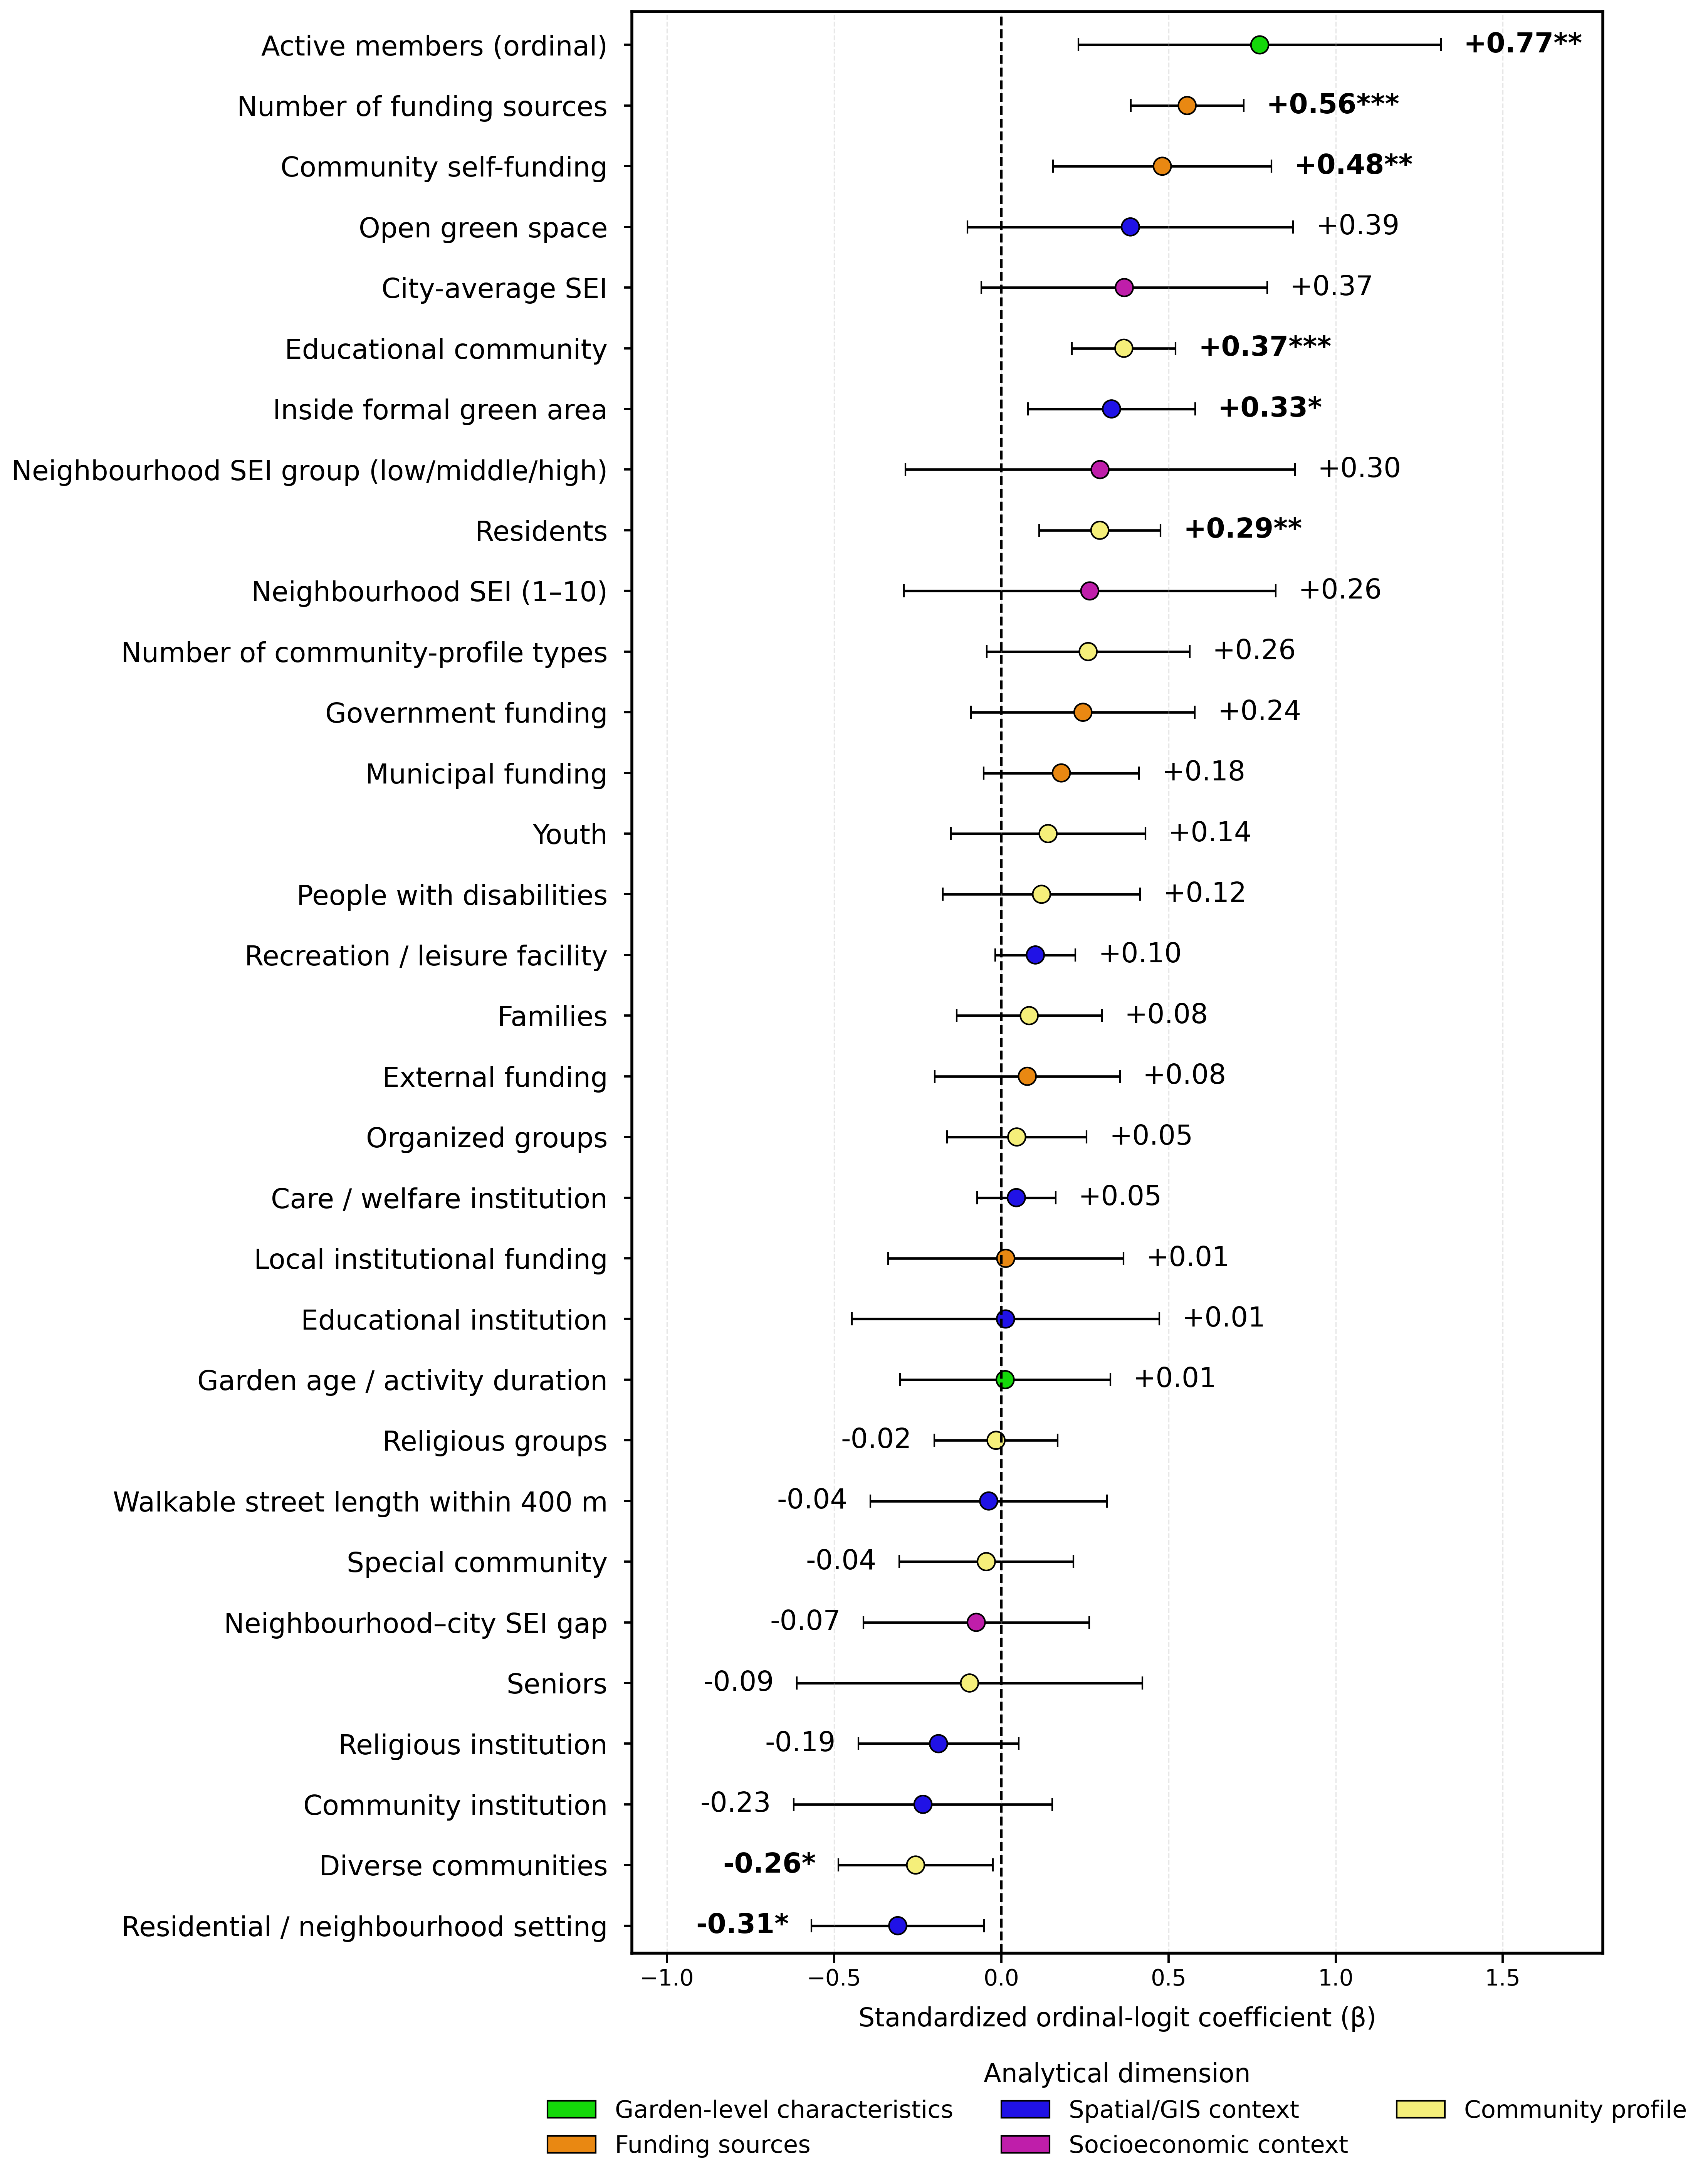

In [9]:
# ============================================================
# 9. Supplementary univariate forest plot
# ============================================================

def plot_univariate_sorted_by_effect(
    results,
    filename="ordinal_univariate_sorted_by_effect_CLEAN.png",
):
    plot_df = results.dropna(
        subset=["coef", "lower", "upper"]
    ).copy()

    if plot_df.empty:
        raise ValueError("No valid univariate coefficients to plot.")

    plot_df = (
        plot_df
        .sort_values("coef", ascending=False)
        .reset_index(drop=True)
    )

    dimension_colors = {
        "Garden-level characteristics": "#14d80a",
        "Funding sources": "#e98812",
        "Spatial/GIS context": "#2012e6",
        "Socioeconomic context": "#bf1eaa",
        "Community profile": "#f5ef7a",
    }

    plot_df["color"] = (
        plot_df["dimension"]
        .map(dimension_colors)
        .fillna("#666666")
    )

    n = len(plot_df)
    fig_h = max(11, 0.52 * n + 3.0)

    fig, ax = plt.subplots(
        figsize=(14, fig_h),
        dpi=300,
    )

    y = np.arange(n)

    xerr = np.vstack([
        plot_df["coef"] - plot_df["lower"],
        plot_df["upper"] - plot_df["coef"],
    ])

    ax.errorbar(
        plot_df["coef"],
        y,
        xerr=xerr,
        fmt="none",
        ecolor="black",
        elinewidth=1.6,
        capsize=4,
        zorder=1,
    )

    ax.scatter(
        plot_df["coef"],
        y,
        s=120,
        c=plot_df["color"],
        edgecolor="black",
        linewidth=1,
        zorder=2,
    )

    x_min = float(plot_df["lower"].min())
    x_max = float(plot_df["upper"].max())
    x_range = max(x_max - x_min, 0.1)
    offset = 0.035 * x_range

    for yi, (_, row) in zip(y, plot_df.iterrows()):
        text = f"{row['coef']:+.2f}{row['stars']}"

        if row["coef"] >= 0:
            x_text = row["upper"] + offset
            ha = "left"
        else:
            x_text = row["lower"] - offset
            ha = "right"

        ax.text(
            x_text,
            yi,
            text,
            va="center",
            ha=ha,
            fontsize=17,
            fontweight="bold" if row["stars"] else "normal",
        )

    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=1.5,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(
        plot_df["label"],
        fontsize=17,
    )

    ax.tick_params(
        axis="x",
        labelsize=14,
        width=1.4,
        length=6,
    )
    ax.tick_params(
        axis="y",
        width=1.4,
        length=5,
        pad=10,
    )

    for spine in ax.spines.values():
        spine.set_linewidth(1.8)
        spine.set_color("black")

    ax.invert_yaxis()

    ax.set_ylim(n - 0.55, -0.55)

    ax.set_xlabel(
        "Standardized ordinal-logit coefficient (β)",
        fontsize=16,
        labelpad=10,
    )

    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.30,
    )

    x_pad = 0.25 * x_range
    ax.set_xlim(
        x_min - x_pad,
        x_max + x_pad,
    )

    legend_handles = [
        Patch(
            facecolor=color,
            edgecolor="black",
            label=dimension,
        )
        for dimension, color in dimension_colors.items()
        if dimension in set(plot_df["dimension"])
    ]

    ax.legend(
        handles=legend_handles,
        title="Analytical dimension",
        loc="upper center",
        bbox_to_anchor=(0.5, -0.045),
        ncol=3,
        frameon=False,
        fontsize=15,
        title_fontsize=16,
    )

    plt.subplots_adjust(
        left=0.37,
        right=0.97,
        top=0.985,
        bottom=0.13,
    )

    safe_savefig(
        fig,
        OUTPUT_DIR,
        filename,
        dpi=400,
    )

    plt.show()


plot_univariate_sorted_by_effect(
    univariate_results,
)


In [10]:
# ============================================================
# 10. Run prespecified adjusted within-dimension models
# ============================================================

model_summary, multivariable_results, design_diagnostics_table = (
    fit_adjusted_ordinal_by_dimension(
        data=df,
        y_col="visitors_ord",
        city_col=CITY,
        dimensions=ADJUSTED_PREDICTORS_BY_DIMENSION,
        labels=pretty_names,
    )
)

model_summary.to_csv(
    OUTPUT_DIR / "ordinal_multivariable_model_summary_by_dimension_CLEAN.csv",
    index=False,
    encoding="utf-8-sig",
)

multivariable_results.to_csv(
    OUTPUT_DIR / "ordinal_multivariable_coefficients_by_dimension_CLEAN.csv",
    index=False,
    encoding="utf-8-sig",
)

design_diagnostics_table.to_csv(
    OUTPUT_DIR / "ordinal_multivariable_design_diagnostics_CLEAN.csv",
    index=False,
    encoding="utf-8-sig",
)

print("\nAdjusted model summary:")
display(model_summary)

print("\nAdjusted coefficients:")
display(multivariable_results)

print("\nDesign-matrix diagnostics:")
display(design_diagnostics_table)

failed_adjusted = model_summary.loc[
    model_summary["error"].astype(str).str.len() > 0
]

if not failed_adjusted.empty:
    print(
        "\nIMPORTANT: at least one prespecified adjusted model failed. "
        "Do not interpret Figure 6 until this is resolved."
    )
    display(
        failed_adjusted[
            ["dimension", "n", "n_cities", "n_predictors", "error"]
        ]
    )



Adjusted model summary:


,dimension,n,n_cities,df_inference,n_predictors,predictors_used,aic,bic,log_likelihood,converged,error
0,Garden-level characteristics,199,13,12,2,"active_members_ord, activity_duration_ord",609.062817,632.115950,-297.531408,True,
1,Socioeconomic context,214,13,12,2,"garden_sei, city_avg_sei",670.069062,693.630894,-328.034531,True,
2,Funding sources,214,13,12,5,"funding_municipal, funding_community_self, fun...",659.388091,693.047851,-319.694045,True,
3,Spatial/GIS context,214,13,12,9,"inside_formal_green_area, walkable_length_400m...",668.458405,715.582069,-320.229202,True,
4,Community profile,214,13,12,9,"community_families, community_educational, com...",675.213833,722.337497,-323.606917,True,



Adjusted coefficients:


,dimension,predictor,label,n,n_cities,df_inference,coef,lower,upper,odds_ratio,or_lower,or_upper,p_value,stars
0,Garden-level characteristics,active_members_ord,Active members (ordinal),199,13,12,0.775563,0.231009,1.320118,2.171815,1.259870,3.743864,0.009137,**
1,Garden-level characteristics,activity_duration_ord,Garden age / activity duration,199,13,12,-0.017075,-0.306516,0.272366,0.983070,0.736007,1.313067,0.899854,
2,Socioeconomic context,garden_sei,Neighbourhood SEI (1–10),214,13,12,0.138723,-0.460584,0.738029,1.148805,0.630915,2.091809,0.623159,
3,Socioeconomic context,city_avg_sei,City-average SEI,214,13,12,0.304754,-0.174042,0.783550,1.356292,0.840262,2.189231,0.190719,
4,Funding sources,funding_municipal,Municipal funding,214,13,12,0.233769,-0.060106,0.527644,1.263353,0.941665,1.694935,0.108657,
5,Funding sources,funding_community_self,Community self-funding,214,13,12,0.569205,0.290394,0.848016,1.766862,1.336954,2.335009,0.000795,***
6,Funding sources,funding_government,Government funding,214,13,12,0.265390,0.046388,0.484392,1.303940,1.047481,1.623188,0.021561,*
7,Funding sources,funding_local_institutional,Local institutional funding,214,13,12,0.027966,-0.281486,0.337417,1.028361,0.754662,1.401324,0.847197,
8,Funding sources,funding_external,External funding,214,13,12,0.208240,0.029738,0.386741,1.231508,1.030185,1.472175,0.025853,*
9,Spatial/GIS context,inside_formal_green_area,Inside formal green area,214,13,12,0.292888,0.002816,0.582961,1.340293,1.002820,1.791334,0.048140,*



Design-matrix diagnostics:


,dimension,n,n_cities,rank,n_predictors,condition_number,max_abs_correlation,high_corr_pairs
0,Garden-level characteristics,199,13,2,2,1.151414,0.140064,
1,Socioeconomic context,214,13,2,2,1.619391,0.447884,
2,Funding sources,214,13,5,5,1.437724,0.253216,
3,Spatial/GIS context,214,13,9,9,2.265373,0.313860,
4,Community profile,214,13,9,9,1.825242,0.324565,


In [11]:
# ============================================================
# 11. Proportional-odds / parallel-slopes diagnostics
# ============================================================
# The proportional-odds model assumes that each variable has the
# same slope across cumulative outcome cutpoints.
#
# We assess this in two complementary ways:
#   1) threshold-specific cumulative binary logistic regressions,
#      fitted on the SAME complete-case sample and with the SAME
#      within-dimension adjustment set as the ordinal model;
#   2) a variable-specific Wald F test for threshold interactions
#      in a stacked cumulative-logit model.
#
# This is a Brant-style parallel-slopes diagnostic, not the
# classical Brant test. The implementation retains the manuscript's
# municipality-clustered robust inference.
#
# Sparse upper cutpoints can make binary-logit diagnostics unstable.
# Therefore only cumulative splits with at least MIN_CUTPOINT_CLASS_N
# gardens on BOTH sides are used for the interaction diagnostic.
# The sparse upper tail is addressed separately in the sensitivity
# analysis in the next cell.
# ============================================================

MIN_CUTPOINT_CLASS_N = 20

PO_LABEL_OVERRIDES = {
    "active_members_ord": "Active members (ordinal)",
    GARDEN_SEI: "Neighbourhood SEI",
    CITY_AVG_SEI: "City-average SEI",
}

def po_label(predictor, labels):
    return PO_LABEL_OVERRIDES.get(
        predictor,
        labels[predictor],
    )

VISIT_LEVEL_LABELS = {
    0: "Up to 100",
    1: "100-500",
    2: "500-1,000",
    3: "1,000-5,000",
    4: "5,000-10,000",
    5: "Above 10,000",
}


def _dimension_complete_case(
    data,
    y_col,
    city_col,
    predictors,
):
    temp = data[[y_col, city_col] + list(predictors)].copy()

    temp[y_col] = pd.to_numeric(
        temp[y_col],
        errors="coerce",
    )

    for predictor in predictors:
        temp[predictor] = pd.to_numeric(
            temp[predictor],
            errors="coerce",
        )

    temp = temp.dropna(
        subset=[y_col, city_col] + list(predictors)
    ).copy()

    temp[y_col] = temp[y_col].astype(int)

    for j, predictor in enumerate(predictors):
        temp[f"_po_x{j}"] = zscore(temp[predictor])

    standardized_cols = [
        f"_po_x{j}"
        for j in range(len(predictors))
    ]

    temp = temp.dropna(
        subset=standardized_cols
    ).copy()

    return temp, standardized_cols


def run_parallel_slopes_diagnostic(
    data,
    y_col,
    city_col,
    dimensions,
    labels,
    min_class_n=20,
):
    """
    Brant-style parallel-slopes diagnostic.

    For each adjusted dimension-specific model:
      - use its exact complete-case sample;
      - standardize variables exactly as in the ordinal model;
      - fit cumulative binary logits at sufficiently supported cutpoints;
      - test, one variable at a time, whether its slope differs across
        retained cutpoints while keeping the other dimension variables
        as common slopes.

    Municipality-clustered robust covariance, finite-sample correction,
    and t/F-based inference are retained.

    IMPORTANT:
    This is not labelled as the classical Brant test because the
    covariance structure is adapted to the municipality-clustered
    analysis used in the manuscript.
    """
    threshold_rows = []
    test_rows = []
    cutpoint_rows = []

    for dimension, predictors in dimensions.items():

        temp, x_cols = _dimension_complete_case(
            data=data,
            y_col=y_col,
            city_col=city_col,
            predictors=predictors,
        )

        predictor_to_x = {
            predictor: x_col
            for predictor, x_col in zip(predictors, x_cols)
        }

        observed_levels = sorted(
            temp[y_col].dropna().unique().astype(int)
        )

        candidate_cutpoints = observed_levels[:-1]
        retained_cutpoints = []

        for cutpoint in candidate_cutpoints:
            binary = (temp[y_col] > cutpoint).astype(int)
            n_high = int(binary.sum())
            n_low = int((1 - binary).sum())
            retained = (
                n_high >= min_class_n
                and n_low >= min_class_n
            )

            cutpoint_rows.append({
                "dimension": dimension,
                "n": len(temp),
                "n_cities": temp[city_col].nunique(),
                "cutpoint": int(cutpoint),
                "cutpoint_label": (
                    f"Higher than {VISIT_LEVEL_LABELS.get(int(cutpoint), cutpoint)}"
                ),
                "n_at_or_below": n_low,
                "n_above": n_high,
                "retained_for_diagnostic": retained,
                "minimum_required_per_side": min_class_n,
            })

            if retained:
                retained_cutpoints.append(int(cutpoint))

        # ----------------------------------------------------
        # A. Threshold-specific cumulative binary-logit slopes
        # ----------------------------------------------------
        for cutpoint in retained_cutpoints:
            binary = (temp[y_col] > cutpoint).astype(int)

            X = sm.add_constant(
                temp[x_cols],
                has_constant="add",
            )

            try:
                result = sm.GLM(
                    binary,
                    X,
                    family=sm.families.Binomial(),
                ).fit(
                    cov_type="cluster",
                    cov_kwds={
                        "groups": temp[city_col],
                        "use_correction": True,
                        "df_correction": True,
                    },
                    use_t=True,
                )

                for predictor, x_col in predictor_to_x.items():
                    ci = result.conf_int().loc[x_col]

                    threshold_rows.append({
                        "dimension": dimension,
                        "predictor": predictor,
                        "label": po_label(predictor, labels),
                        "n": len(temp),
                        "n_cities": temp[city_col].nunique(),
                        "cutpoint": cutpoint,
                        "cutpoint_label": (
                            f"Higher than {VISIT_LEVEL_LABELS.get(cutpoint, cutpoint)}"
                        ),
                        "n_at_or_below": int((1 - binary).sum()),
                        "n_above": int(binary.sum()),
                        "coef": float(result.params[x_col]),
                        "lower": float(ci.iloc[0]),
                        "upper": float(ci.iloc[1]),
                        "p_value": float(result.pvalues[x_col]),
                        "converged": bool(
                            getattr(
                                result,
                                "converged",
                                True,
                            )
                        ),
                        "error": "",
                    })

            except Exception as exc:
                for predictor in predictors:
                    threshold_rows.append({
                        "dimension": dimension,
                        "predictor": predictor,
                        "label": po_label(predictor, labels),
                        "n": len(temp),
                        "n_cities": temp[city_col].nunique(),
                        "cutpoint": cutpoint,
                        "cutpoint_label": (
                            f"Higher than {VISIT_LEVEL_LABELS.get(cutpoint, cutpoint)}"
                        ),
                        "n_at_or_below": int((1 - binary).sum()),
                        "n_above": int(binary.sum()),
                        "coef": np.nan,
                        "lower": np.nan,
                        "upper": np.nan,
                        "p_value": np.nan,
                        "converged": False,
                        "error": repr(exc),
                    })

        # ----------------------------------------------------
        # B. Variable-specific threshold-interaction Wald tests
        # ----------------------------------------------------
        if len(retained_cutpoints) < 2:
            for predictor in predictors:
                test_rows.append({
                    "dimension": dimension,
                    "predictor": predictor,
                    "label": po_label(predictor, labels),
                    "n": len(temp),
                    "n_cities": temp[city_col].nunique(),
                    "cutpoints_tested": "",
                    "n_cutpoints": len(retained_cutpoints),
                    "wald_f": np.nan,
                    "df_num": np.nan,
                    "df_denom": np.nan,
                    "p_value": np.nan,
                    "error": (
                        "Fewer than two adequately supported cumulative "
                        "cutpoints; threshold-interaction test not fitted."
                    ),
                })
            continue

        stacked_blocks = []

        for cutpoint in retained_cutpoints:
            block = temp[
                [city_col] + x_cols
            ].copy()

            block["_po_cutpoint"] = str(cutpoint)
            block["_po_binary"] = (
                temp[y_col] > cutpoint
            ).astype(int).to_numpy()

            stacked_blocks.append(block)

        stacked = pd.concat(
            stacked_blocks,
            axis=0,
            ignore_index=True,
        )

        common_terms = (
            ["C(_po_cutpoint)"]
            + x_cols
        )

        for predictor, tested_x in predictor_to_x.items():

            formula = (
                "_po_binary ~ "
                + " + ".join(common_terms)
                + f" + C(_po_cutpoint):{tested_x}"
            )

            predictor_values = temp[predictor].dropna()
            unique_values = set(
                pd.to_numeric(
                    predictor_values,
                    errors="coerce",
                ).dropna().unique()
            )

            binary_predictor_min_group_n = np.nan
            if unique_values.issubset({0, 1}) and len(unique_values) == 2:
                counts = predictor_values.value_counts()
                binary_predictor_min_group_n = int(counts.min())

            try:
                result = smf.glm(
                    formula=formula,
                    data=stacked,
                    family=sm.families.Binomial(),
                ).fit(
                    cov_type="cluster",
                    cov_kwds={
                        "groups": stacked[city_col],
                        "use_correction": True,
                        "df_correction": True,
                    },
                    use_t=True,
                )

                interaction_terms = [
                    name
                    for name in result.params.index
                    if (
                        "C(_po_cutpoint)" in name
                        and (
                            f":{tested_x}" in name
                            or f"{tested_x}:" in name
                        )
                    )
                ]

                if not interaction_terms:
                    raise RuntimeError(
                        "No threshold-interaction terms found in fitted model."
                    )

                R = np.zeros(
                    (
                        len(interaction_terms),
                        len(result.params),
                    )
                )

                for row_i, term in enumerate(interaction_terms):
                    col_i = result.params.index.get_loc(term)
                    R[row_i, col_i] = 1.0

                wald = result.wald_test(
                    R,
                    use_f=True,
                    scalar=True,
                )

                wald_f = float(np.asarray(wald.statistic))
                p_value = float(wald.pvalue)

                if (
                    not np.isfinite(wald_f)
                    or wald_f < 0
                    or not np.isfinite(p_value)
                ):
                    raise RuntimeError(
                        "Unstable Wald statistic; covariance matrix may be "
                        "ill-conditioned for this diagnostic."
                    )

                test_rows.append({
                    "dimension": dimension,
                    "predictor": predictor,
                    "label": po_label(predictor, labels),
                    "n": len(temp),
                    "n_cities": temp[city_col].nunique(),
                    "cutpoints_tested": ", ".join(
                        str(x) for x in retained_cutpoints
                    ),
                    "n_cutpoints": len(retained_cutpoints),
                    "binary_predictor_min_group_n": (
                        binary_predictor_min_group_n
                    ),
                    "wald_f": wald_f,
                    "df_num": float(
                        getattr(
                            wald,
                            "df_num",
                            len(interaction_terms),
                        )
                    ),
                    "df_denom": float(
                        getattr(
                            wald,
                            "df_denom",
                            temp[city_col].nunique() - 1,
                        )
                    ),
                    "p_value": p_value,
                    "error": "",
                })

            except Exception as exc:
                test_rows.append({
                    "dimension": dimension,
                    "predictor": predictor,
                    "label": po_label(predictor, labels),
                    "n": len(temp),
                    "n_cities": temp[city_col].nunique(),
                    "cutpoints_tested": ", ".join(
                        str(x) for x in retained_cutpoints
                    ),
                    "n_cutpoints": len(retained_cutpoints),
                    "binary_predictor_min_group_n": (
                        binary_predictor_min_group_n
                    ),
                    "wald_f": np.nan,
                    "df_num": np.nan,
                    "df_denom": np.nan,
                    "p_value": np.nan,
                    "error": repr(exc),
                })

    threshold_table = pd.DataFrame(threshold_rows)
    test_table = pd.DataFrame(test_rows)
    cutpoint_table = pd.DataFrame(cutpoint_rows)

    if not test_table.empty:
        test_table["p_holm_within_dimension"] = np.nan

        for dimension in test_table["dimension"].dropna().unique():
            mask = (
                (test_table["dimension"] == dimension)
                & test_table["p_value"].notna()
            )

            if mask.any():
                adjusted = multipletests(
                    test_table.loc[mask, "p_value"],
                    method="holm",
                )[1]

                test_table.loc[
                    mask,
                    "p_holm_within_dimension",
                ] = adjusted

        test_table["evidence_nonparallel_raw_p05"] = (
            test_table["p_value"] < 0.05
        )

        test_table["evidence_nonparallel_holm_p05"] = (
            test_table["p_holm_within_dimension"] < 0.05
        )

    return threshold_table, test_table, cutpoint_table


(
    po_threshold_coefficients,
    po_parallel_slopes_tests,
    po_cutpoint_support,
) = run_parallel_slopes_diagnostic(
    data=df,
    y_col="visitors_ord",
    city_col=CITY,
    dimensions=ADJUSTED_PREDICTORS_BY_DIMENSION,
    labels=pretty_names,
    min_class_n=MIN_CUTPOINT_CLASS_N,
)

po_threshold_coefficients.to_csv(
    OUTPUT_DIR / "proportional_odds_threshold_coefficients.csv",
    index=False,
    encoding="utf-8-sig",
)

po_parallel_slopes_tests.to_csv(
    OUTPUT_DIR / "proportional_odds_parallel_slopes_tests.csv",
    index=False,
    encoding="utf-8-sig",
)

po_cutpoint_support.to_csv(
    OUTPUT_DIR / "proportional_odds_cutpoint_support.csv",
    index=False,
    encoding="utf-8-sig",
)

print("\nCumulative cutpoint support:")
display(po_cutpoint_support)

print("\nParallel-slopes variable tests:")
display(
    po_parallel_slopes_tests[
        [
            "dimension",
            "label",
            "n",
            "n_cities",
            "cutpoints_tested",
            "binary_predictor_min_group_n",
            "wald_f",
            "df_num",
            "df_denom",
            "p_value",
            "p_holm_within_dimension",
            "evidence_nonparallel_holm_p05",
            "error",
        ]
    ]
)

print(
    "\nInterpretation: a small p-value indicates evidence that a "
    "variable's cumulative-logit slope differs across the retained "
    "cutpoints. Because upper annual-visit categories are sparse, "
    "the next cell provides an outcome-collapsing sensitivity analysis."
)



Cumulative cutpoint support:


,dimension,n,n_cities,cutpoint,cutpoint_label,n_at_or_below,n_above,retained_for_diagnostic,minimum_required_per_side
0,Garden-level characteristics,199,13,0,Higher than Up to 100,57,142,True,20
1,Garden-level characteristics,199,13,1,Higher than 100-500,114,85,True,20
2,Garden-level characteristics,199,13,2,"Higher than 500-1,000",154,45,True,20
3,Garden-level characteristics,199,13,3,"Higher than 1,000-5,000",183,16,False,20
4,Garden-level characteristics,199,13,4,"Higher than 5,000-10,000",190,9,False,20
5,Socioeconomic context,214,13,0,Higher than Up to 100,70,144,True,20
6,Socioeconomic context,214,13,1,Higher than 100-500,127,87,True,20
7,Socioeconomic context,214,13,2,"Higher than 500-1,000",168,46,True,20
8,Socioeconomic context,214,13,3,"Higher than 1,000-5,000",198,16,False,20
9,Socioeconomic context,214,13,4,"Higher than 5,000-10,000",205,9,False,20



Parallel-slopes variable tests:


,dimension,label,n,n_cities,cutpoints_tested,binary_predictor_min_group_n,wald_f,df_num,df_denom,p_value,p_holm_within_dimension,evidence_nonparallel_holm_p05,error
0,Garden-level characteristics,Active members (ordinal),199,13,"0, 1, 2",NaN,1.822286,2.0,12.0,0.203660,0.278763,False,
1,Garden-level characteristics,Garden age / activity duration,199,13,"0, 1, 2",NaN,2.332662,2.0,12.0,0.139381,0.278763,False,
2,Socioeconomic context,Neighbourhood SEI,214,13,"0, 1, 2",NaN,0.653424,2.0,12.0,0.537819,0.537819,False,
3,Socioeconomic context,City-average SEI,214,13,"0, 1, 2",NaN,1.566638,2.0,12.0,0.248593,0.497187,False,
4,Funding sources,Municipal funding,214,13,"0, 1, 2",5.0,NaN,NaN,NaN,NaN,NaN,False,RuntimeError('Unstable Wald statistic; covaria...
5,Funding sources,Community self-funding,214,13,"0, 1, 2",84.0,0.715377,2.0,12.0,0.508727,0.691951,False,
6,Funding sources,Government funding,214,13,"0, 1, 2",28.0,7.456256,2.0,12.0,0.007859,0.031436,True,
7,Funding sources,Local institutional funding,214,13,"0, 1, 2",23.0,1.811529,2.0,12.0,0.205348,0.616045,False,
8,Funding sources,External funding,214,13,"0, 1, 2",22.0,1.161055,2.0,12.0,0.345976,0.691951,False,
9,Spatial/GIS context,Inside formal green area,214,13,"0, 1, 2",47.0,2.740042,2.0,12.0,0.104671,0.796502,False,



Interpretation: a small p-value indicates evidence that a variable's cumulative-logit slope differs across the retained cutpoints. Because upper annual-visit categories are sparse, the next cell provides an outcome-collapsing sensitivity analysis.


In [12]:
# ============================================================
# 12. Sensitivity analysis for the sparse upper annual-visit tail
# ============================================================
# The original six-level annual-visit outcome has only:
#   - 7 gardens in 5,000-10,000 visits
#   - 9 gardens above 10,000 visits
#
# As a robustness check, the three upper levels are collapsed into:
#   >= 1,000 annual visits
#
# This yields a four-level ordinal outcome:
#   0 = up to 100
#   1 = 100-500
#   2 = 500-1,000
#   3 = >= 1,000
#
# The original six-level models remain the PRIMARY analysis.
# ============================================================

df["visitors_ord_4level_sensitivity"] = (
    df["visitors_ord"]
    .map(
        lambda value: (
            np.nan
            if pd.isna(value)
            else min(int(value), 3)
        )
    )
    .astype(float)
)

print("\nFour-level sensitivity outcome distribution:")
display(
    df["visitors_ord_4level_sensitivity"]
    .value_counts(dropna=False)
    .sort_index()
)

(
    sensitivity_4level_model_summary,
    sensitivity_4level_coefficients,
    sensitivity_4level_design_diagnostics,
) = fit_adjusted_ordinal_by_dimension(
    data=df,
    y_col="visitors_ord_4level_sensitivity",
    city_col=CITY,
    dimensions=ADJUSTED_PREDICTORS_BY_DIMENSION,
    labels=pretty_names,
)

sensitivity_4level_model_summary.to_csv(
    OUTPUT_DIR / "ordinal_4level_sensitivity_model_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

sensitivity_4level_coefficients.to_csv(
    OUTPUT_DIR / "ordinal_4level_sensitivity_coefficients.csv",
    index=False,
    encoding="utf-8-sig",
)

sensitivity_comparison = (
    multivariable_results[
        [
            "dimension",
            "predictor",
            "label",
            "coef",
            "lower",
            "upper",
            "p_value",
        ]
    ]
    .merge(
        sensitivity_4level_coefficients[
            [
                "dimension",
                "predictor",
                "coef",
                "lower",
                "upper",
                "p_value",
            ]
        ],
        on=["dimension", "predictor"],
        how="left",
        suffixes=("_primary_6level", "_sensitivity_4level"),
    )
)

sensitivity_comparison["same_coefficient_direction"] = (
    np.sign(sensitivity_comparison["coef_primary_6level"])
    == np.sign(sensitivity_comparison["coef_sensitivity_4level"])
)

sensitivity_comparison["significant_primary_p05"] = (
    sensitivity_comparison["p_value_primary_6level"] < 0.05
)

sensitivity_comparison["significant_sensitivity_p05"] = (
    sensitivity_comparison["p_value_sensitivity_4level"] < 0.05
)

sensitivity_comparison["primary_significant_result_retained"] = np.where(
    sensitivity_comparison["significant_primary_p05"],
    (
        sensitivity_comparison["same_coefficient_direction"]
        & sensitivity_comparison["significant_sensitivity_p05"]
    ),
    np.nan,
)

sensitivity_comparison.to_csv(
    OUTPUT_DIR / "ordinal_4level_sensitivity_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

po_diagnostic_summary = (
    sensitivity_comparison
    .merge(
        po_parallel_slopes_tests[
            [
                "dimension",
                "predictor",
                "cutpoints_tested",
                "wald_f",
                "df_num",
                "df_denom",
                "p_value",
                "p_holm_within_dimension",
                "evidence_nonparallel_holm_p05",
                "binary_predictor_min_group_n",
                "error",
            ]
        ].rename(
            columns={
                "p_value": "parallel_slopes_p_value",
                "error": "parallel_slopes_error",
            }
        ),
        on=["dimension", "predictor"],
        how="left",
    )
)

po_diagnostic_summary.to_csv(
    OUTPUT_DIR / "proportional_odds_and_sensitivity_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

print("\nPrimary vs four-level sensitivity comparison:")
display(
    sensitivity_comparison[
        [
            "dimension",
            "label",
            "coef_primary_6level",
            "p_value_primary_6level",
            "coef_sensitivity_4level",
            "p_value_sensitivity_4level",
            "same_coefficient_direction",
            "significant_primary_p05",
            "significant_sensitivity_p05",
            "primary_significant_result_retained",
        ]
    ]
)

primary_sig = sensitivity_comparison.loc[
    sensitivity_comparison["significant_primary_p05"]
].copy()

all_primary_retained = bool(
    primary_sig["primary_significant_result_retained"]
    .fillna(False)
    .all()
)

print(
    "\nPrimary significant associations retained in the "
    f"four-level sensitivity model: {all_primary_retained}"
)

if not primary_sig.empty:
    print("\nPrimary significant associations:")
    display(
        po_diagnostic_summary.loc[
            po_diagnostic_summary["significant_primary_p05"],
            [
                "dimension",
                "label",
                "coef_primary_6level",
                "p_value_primary_6level",
                "coef_sensitivity_4level",
                "p_value_sensitivity_4level",
                "parallel_slopes_p_value",
                "p_holm_within_dimension",
                "evidence_nonparallel_holm_p05",
                "binary_predictor_min_group_n",
                "parallel_slopes_error",
            ],
        ]
    )

print(
    "\nImportant: the four-level model is a sensitivity analysis. "
    "It does not replace the primary six-level proportional-odds model."
)



Four-level sensitivity outcome distribution:


visitors_ord_4level_sensitivity
0.0    70
1.0    57
2.0    41
3.0    46
NaN    77
Name: count, dtype: int64


Primary vs four-level sensitivity comparison:


,dimension,label,coef_primary_6level,p_value_primary_6level,coef_sensitivity_4level,p_value_sensitivity_4level,same_coefficient_direction,significant_primary_p05,significant_sensitivity_p05,primary_significant_result_retained
0,Garden-level characteristics,Active members (ordinal),0.775563,0.009137,0.814060,0.013902,True,True,True,1.0
1,Garden-level characteristics,Garden age / activity duration,-0.017075,0.899854,-0.031690,0.826636,True,False,False,NaN
2,Socioeconomic context,Neighbourhood SEI (1–10),0.138723,0.623159,0.136389,0.625410,True,False,False,NaN
3,Socioeconomic context,City-average SEI,0.304754,0.190719,0.310534,0.197194,True,False,False,NaN
4,Funding sources,Municipal funding,0.233769,0.108657,0.232670,0.109888,True,False,False,NaN
5,Funding sources,Community self-funding,0.569205,0.000795,0.581278,0.001046,True,True,True,1.0
6,Funding sources,Government funding,0.265390,0.021561,0.274235,0.022371,True,True,True,1.0
7,Funding sources,Local institutional funding,0.027966,0.847197,0.008329,0.950932,True,False,False,NaN
8,Funding sources,External funding,0.208240,0.025853,0.201670,0.029794,True,True,True,1.0
9,Spatial/GIS context,Inside formal green area,0.292888,0.048140,0.303839,0.045719,True,True,True,1.0



Primary significant associations retained in the four-level sensitivity model: True

Primary significant associations:


,dimension,label,coef_primary_6level,p_value_primary_6level,coef_sensitivity_4level,p_value_sensitivity_4level,parallel_slopes_p_value,p_holm_within_dimension,evidence_nonparallel_holm_p05,binary_predictor_min_group_n,parallel_slopes_error
0,Garden-level characteristics,Active members (ordinal),0.775563,0.009137,0.814060,0.013902,0.203660,0.278763,False,NaN,
5,Funding sources,Community self-funding,0.569205,0.000795,0.581278,0.001046,0.508727,0.691951,False,84.0,
6,Funding sources,Government funding,0.265390,0.021561,0.274235,0.022371,0.007859,0.031436,True,28.0,
8,Funding sources,External funding,0.208240,0.025853,0.201670,0.029794,0.345976,0.691951,False,22.0,
9,Spatial/GIS context,Inside formal green area,0.292888,0.048140,0.303839,0.045719,0.104671,0.796502,False,47.0,
14,Spatial/GIS context,Residential / neighbourhood setting,-0.304283,0.017549,-0.290366,0.026272,0.952072,1.000000,False,54.0,
19,Community profile,Educational community,0.285105,0.000566,0.257948,0.002853,0.062992,0.503939,False,52.0,
22,Community profile,Residents,0.232999,0.041975,0.224644,0.036206,0.133348,0.755500,False,42.0,



Important: the four-level model is a sensitivity analysis. It does not replace the primary six-level proportional-odds model.


In [13]:
# ============================================================
# 13. Key diagnostic checks: display on screen + save as files
# ============================================================
# These are the two concise diagnostic tables intended for review:
#   A. Proportional-odds / parallel-slopes assumption check
#   B. Four-level upper-tail sensitivity check
#
# Both tables are:
#   - displayed on screen below this cell; and
#   - saved automatically in the output_statistics folder.
# ============================================================

# ------------------------------------------------------------
# A. Proportional-odds / parallel-slopes assumption check
# ------------------------------------------------------------

proportional_odds_check = (
    po_parallel_slopes_tests[
        [
            "dimension",
            "label",
            "n",
            "n_cities",
            "cutpoints_tested",
            "wald_f",
            "df_num",
            "df_denom",
            "p_value",
            "p_holm_within_dimension",
            "evidence_nonparallel_holm_p05",
            "binary_predictor_min_group_n",
            "error",
        ]
    ]
    .copy()
    .rename(
        columns={
            "label": "variable",
            "p_value": "parallel_slopes_p_value",
            "p_holm_within_dimension": "holm_adjusted_p_value",
            "evidence_nonparallel_holm_p05":
                "evidence_against_proportional_odds_p05",
        }
    )
)

proportional_odds_file = (
    OUTPUT_DIR / "proportional_odds_assumption_check.csv"
)

proportional_odds_check.to_csv(
    proportional_odds_file,
    index=False,
    encoding="utf-8-sig",
)

print("\n" + "=" * 88)
print("A. PROPORTIONAL-ODDS / PARALLEL-SLOPES ASSUMPTION CHECK")
print("=" * 88)
print(f"Saved to: {proportional_odds_file.resolve()}")
display(proportional_odds_check)


# ------------------------------------------------------------
# B. Four-level upper-tail sensitivity check
# ------------------------------------------------------------

four_level_sensitivity_check = (
    sensitivity_comparison[
        [
            "dimension",
            "label",
            "coef_primary_6level",
            "p_value_primary_6level",
            "coef_sensitivity_4level",
            "p_value_sensitivity_4level",
            "same_coefficient_direction",
            "significant_primary_p05",
            "significant_sensitivity_p05",
            "primary_significant_result_retained",
        ]
    ]
    .copy()
    .rename(
        columns={
            "label": "variable",
        }
    )
)

four_level_sensitivity_file = (
    OUTPUT_DIR / "four_level_annual_visit_sensitivity_check.csv"
)

four_level_sensitivity_check.to_csv(
    four_level_sensitivity_file,
    index=False,
    encoding="utf-8-sig",
)

print("\n" + "=" * 88)
print("B. FOUR-LEVEL ANNUAL-VISIT SENSITIVITY CHECK")
print("=" * 88)
print(f"Saved to: {four_level_sensitivity_file.resolve()}")
display(four_level_sensitivity_check)


# ------------------------------------------------------------
# Short on-screen summary of the primary significant findings
# ------------------------------------------------------------

primary_significant_diagnostics = (
    po_diagnostic_summary.loc[
        po_diagnostic_summary["significant_primary_p05"],
        [
            "dimension",
            "label",
            "coef_primary_6level",
            "p_value_primary_6level",
            "coef_sensitivity_4level",
            "p_value_sensitivity_4level",
            "parallel_slopes_p_value",
            "p_holm_within_dimension",
            "evidence_nonparallel_holm_p05",
        ],
    ]
    .copy()
)

print("\n" + "=" * 88)
print("PRIMARY SIGNIFICANT ASSOCIATIONS — DIAGNOSTIC SUMMARY")
print("=" * 88)
display(primary_significant_diagnostics)

print(
    "\nFiles created in output_statistics:\n"
    f" - {proportional_odds_file.name}\n"
    f" - {four_level_sensitivity_file.name}\n"
)



A. PROPORTIONAL-ODDS / PARALLEL-SLOPES ASSUMPTION CHECK
Saved to: C:\Users\galia\Desktop\CGs Israel Code\output_statistics\proportional_odds_assumption_check.csv


,dimension,variable,n,n_cities,cutpoints_tested,wald_f,df_num,df_denom,parallel_slopes_p_value,holm_adjusted_p_value,evidence_against_proportional_odds_p05,binary_predictor_min_group_n,error
0,Garden-level characteristics,Active members (ordinal),199,13,"0, 1, 2",1.822286,2.0,12.0,0.203660,0.278763,False,NaN,
1,Garden-level characteristics,Garden age / activity duration,199,13,"0, 1, 2",2.332662,2.0,12.0,0.139381,0.278763,False,NaN,
2,Socioeconomic context,Neighbourhood SEI,214,13,"0, 1, 2",0.653424,2.0,12.0,0.537819,0.537819,False,NaN,
3,Socioeconomic context,City-average SEI,214,13,"0, 1, 2",1.566638,2.0,12.0,0.248593,0.497187,False,NaN,
4,Funding sources,Municipal funding,214,13,"0, 1, 2",NaN,NaN,NaN,NaN,NaN,False,5.0,RuntimeError('Unstable Wald statistic; covaria...
5,Funding sources,Community self-funding,214,13,"0, 1, 2",0.715377,2.0,12.0,0.508727,0.691951,False,84.0,
6,Funding sources,Government funding,214,13,"0, 1, 2",7.456256,2.0,12.0,0.007859,0.031436,True,28.0,
7,Funding sources,Local institutional funding,214,13,"0, 1, 2",1.811529,2.0,12.0,0.205348,0.616045,False,23.0,
8,Funding sources,External funding,214,13,"0, 1, 2",1.161055,2.0,12.0,0.345976,0.691951,False,22.0,
9,Spatial/GIS context,Inside formal green area,214,13,"0, 1, 2",2.740042,2.0,12.0,0.104671,0.796502,False,47.0,



B. FOUR-LEVEL ANNUAL-VISIT SENSITIVITY CHECK
Saved to: C:\Users\galia\Desktop\CGs Israel Code\output_statistics\four_level_annual_visit_sensitivity_check.csv


,dimension,variable,coef_primary_6level,p_value_primary_6level,coef_sensitivity_4level,p_value_sensitivity_4level,same_coefficient_direction,significant_primary_p05,significant_sensitivity_p05,primary_significant_result_retained
0,Garden-level characteristics,Active members (ordinal),0.775563,0.009137,0.814060,0.013902,True,True,True,1.0
1,Garden-level characteristics,Garden age / activity duration,-0.017075,0.899854,-0.031690,0.826636,True,False,False,NaN
2,Socioeconomic context,Neighbourhood SEI (1–10),0.138723,0.623159,0.136389,0.625410,True,False,False,NaN
3,Socioeconomic context,City-average SEI,0.304754,0.190719,0.310534,0.197194,True,False,False,NaN
4,Funding sources,Municipal funding,0.233769,0.108657,0.232670,0.109888,True,False,False,NaN
5,Funding sources,Community self-funding,0.569205,0.000795,0.581278,0.001046,True,True,True,1.0
6,Funding sources,Government funding,0.265390,0.021561,0.274235,0.022371,True,True,True,1.0
7,Funding sources,Local institutional funding,0.027966,0.847197,0.008329,0.950932,True,False,False,NaN
8,Funding sources,External funding,0.208240,0.025853,0.201670,0.029794,True,True,True,1.0
9,Spatial/GIS context,Inside formal green area,0.292888,0.048140,0.303839,0.045719,True,True,True,1.0



PRIMARY SIGNIFICANT ASSOCIATIONS — DIAGNOSTIC SUMMARY


,dimension,label,coef_primary_6level,p_value_primary_6level,coef_sensitivity_4level,p_value_sensitivity_4level,parallel_slopes_p_value,p_holm_within_dimension,evidence_nonparallel_holm_p05
0,Garden-level characteristics,Active members (ordinal),0.775563,0.009137,0.814060,0.013902,0.203660,0.278763,False
5,Funding sources,Community self-funding,0.569205,0.000795,0.581278,0.001046,0.508727,0.691951,False
6,Funding sources,Government funding,0.265390,0.021561,0.274235,0.022371,0.007859,0.031436,True
8,Funding sources,External funding,0.208240,0.025853,0.201670,0.029794,0.345976,0.691951,False
9,Spatial/GIS context,Inside formal green area,0.292888,0.048140,0.303839,0.045719,0.104671,0.796502,False
14,Spatial/GIS context,Residential / neighbourhood setting,-0.304283,0.017549,-0.290366,0.026272,0.952072,1.000000,False
19,Community profile,Educational community,0.285105,0.000566,0.257948,0.002853,0.062992,0.503939,False
22,Community profile,Residents,0.232999,0.041975,0.224644,0.036206,0.133348,0.755500,False



Files created in output_statistics:
 - proportional_odds_assumption_check.csv
 - four_level_annual_visit_sensitivity_check.csv



In [14]:
# ============================================================
# 14. Common-sample AIC/BIC comparison
# ============================================================
# AIC/BIC compare likelihood fit and complexity. Robust covariance
# affects inference, not the maximum-likelihood value, so the common-
# sample comparison is fitted without a robust covariance request.

def compare_dimension_models_common_sample(
    data,
    y_col,
    city_col,
    dimensions,
):
    all_predictors = sorted({
        predictor
        for predictors in dimensions.values()
        for predictor in predictors
    })

    common = data[
        [y_col, city_col] + all_predictors
    ].copy()

    common[y_col] = pd.to_numeric(
        common[y_col],
        errors="coerce",
    )

    for predictor in all_predictors:
        common[predictor] = pd.to_numeric(
            common[predictor],
            errors="coerce",
        )

    common = common.dropna(
        subset=[y_col, city_col] + all_predictors
    ).copy()

    common[y_col] = common[y_col].astype(int)

    print(
        f"Common AIC/BIC sample: {len(common)} gardens, "
        f"{common[city_col].nunique()} cities"
    )

    rows = []

    for dimension, predictors in dimensions.items():
        X = common[list(predictors)].apply(
            zscore,
            axis=0,
        )

        diagnostics = design_diagnostics(X)

        if diagnostics["rank"] < diagnostics["n_predictors"]:
            rows.append({
                "dimension": dimension,
                "n": len(common),
                "n_cities": common[city_col].nunique(),
                "n_predictors": len(predictors),
                "predictors_used": ", ".join(predictors),
                "aic": np.nan,
                "bic": np.nan,
                "log_likelihood": np.nan,
                "converged": False,
                "error": "rank-deficient design matrix",
            })
            continue

        try:
            model = OrderedModel(
                common[y_col],
                X,
                distr="logit",
            )

            result = model.fit(
                method="bfgs",
                maxiter=1000,
                disp=False,
            )

            rows.append({
                "dimension": dimension,
                "n": len(common),
                "n_cities": common[city_col].nunique(),
                "n_predictors": len(predictors),
                "predictors_used": ", ".join(predictors),
                "aic": float(result.aic),
                "bic": float(result.bic),
                "log_likelihood": float(result.llf),
                "converged": bool(
                    getattr(
                        result,
                        "mle_retvals",
                        {},
                    ).get("converged", True)
                ),
                "error": "",
            })

        except Exception as exc:
            rows.append({
                "dimension": dimension,
                "n": len(common),
                "n_cities": common[city_col].nunique(),
                "n_predictors": len(predictors),
                "predictors_used": ", ".join(predictors),
                "aic": np.nan,
                "bic": np.nan,
                "log_likelihood": np.nan,
                "converged": False,
                "error": repr(exc),
            })

    out = pd.DataFrame(rows)

    valid = out["aic"].notna()
    if valid.any():
        out.loc[valid, "delta_aic"] = (
            out.loc[valid, "aic"]
            - out.loc[valid, "aic"].min()
        )

        weights = np.exp(
            -0.5 * out.loc[valid, "delta_aic"]
        )
        out.loc[valid, "akaike_weight"] = (
            weights / weights.sum()
        )

    return out, common


aic_common_sample, common_model_sample = (
    compare_dimension_models_common_sample(
        data=df,
        y_col="visitors_ord",
        city_col=CITY,
        dimensions=ADJUSTED_PREDICTORS_BY_DIMENSION,
    )
)

aic_common_sample = (
    aic_common_sample
    .sort_values("aic", na_position="last")
    .reset_index(drop=True)
)

aic_common_sample.to_csv(
    OUTPUT_DIR / "ordinal_dimension_AIC_BIC_common_sample_CLEAN.csv",
    index=False,
    encoding="utf-8-sig",
)

display(aic_common_sample)


Common AIC/BIC sample: 199 gardens, 13 cities


,dimension,n,n_cities,n_predictors,predictors_used,aic,bic,log_likelihood,converged,error,delta_aic,akaike_weight
0,Garden-level characteristics,199,13,2,"active_members_ord, activity_duration_ord",609.062817,632.115950,-297.531408,True,,0.000000,9.999316e-01
1,Funding sources,199,13,5,"funding_municipal, funding_community_self, fun...",629.078024,662.011072,-304.539012,True,,20.015207,4.505296e-05
2,Spatial/GIS context,199,13,9,"inside_formal_green_area, walkable_length_400m...",630.458053,676.564320,-301.229026,True,,21.395236,2.259716e-05
3,Socioeconomic context,199,13,2,"garden_sei, city_avg_sei",637.684837,660.737970,-311.842418,True,,28.622020,6.092249e-07
4,Community profile,199,13,9,"community_families, community_educational, com...",640.053182,686.159450,-306.026591,True,,30.990365,1.864223e-07


C:\Users\galia\AppData\Local\Temp\ipykernel_44920\4274031948.py:281: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(


Saved:
 - output_statistics\ordinal_multivariable_custom_layout_CLEAN.png
 - output_statistics\ordinal_multivariable_custom_layout_CLEAN.pdf


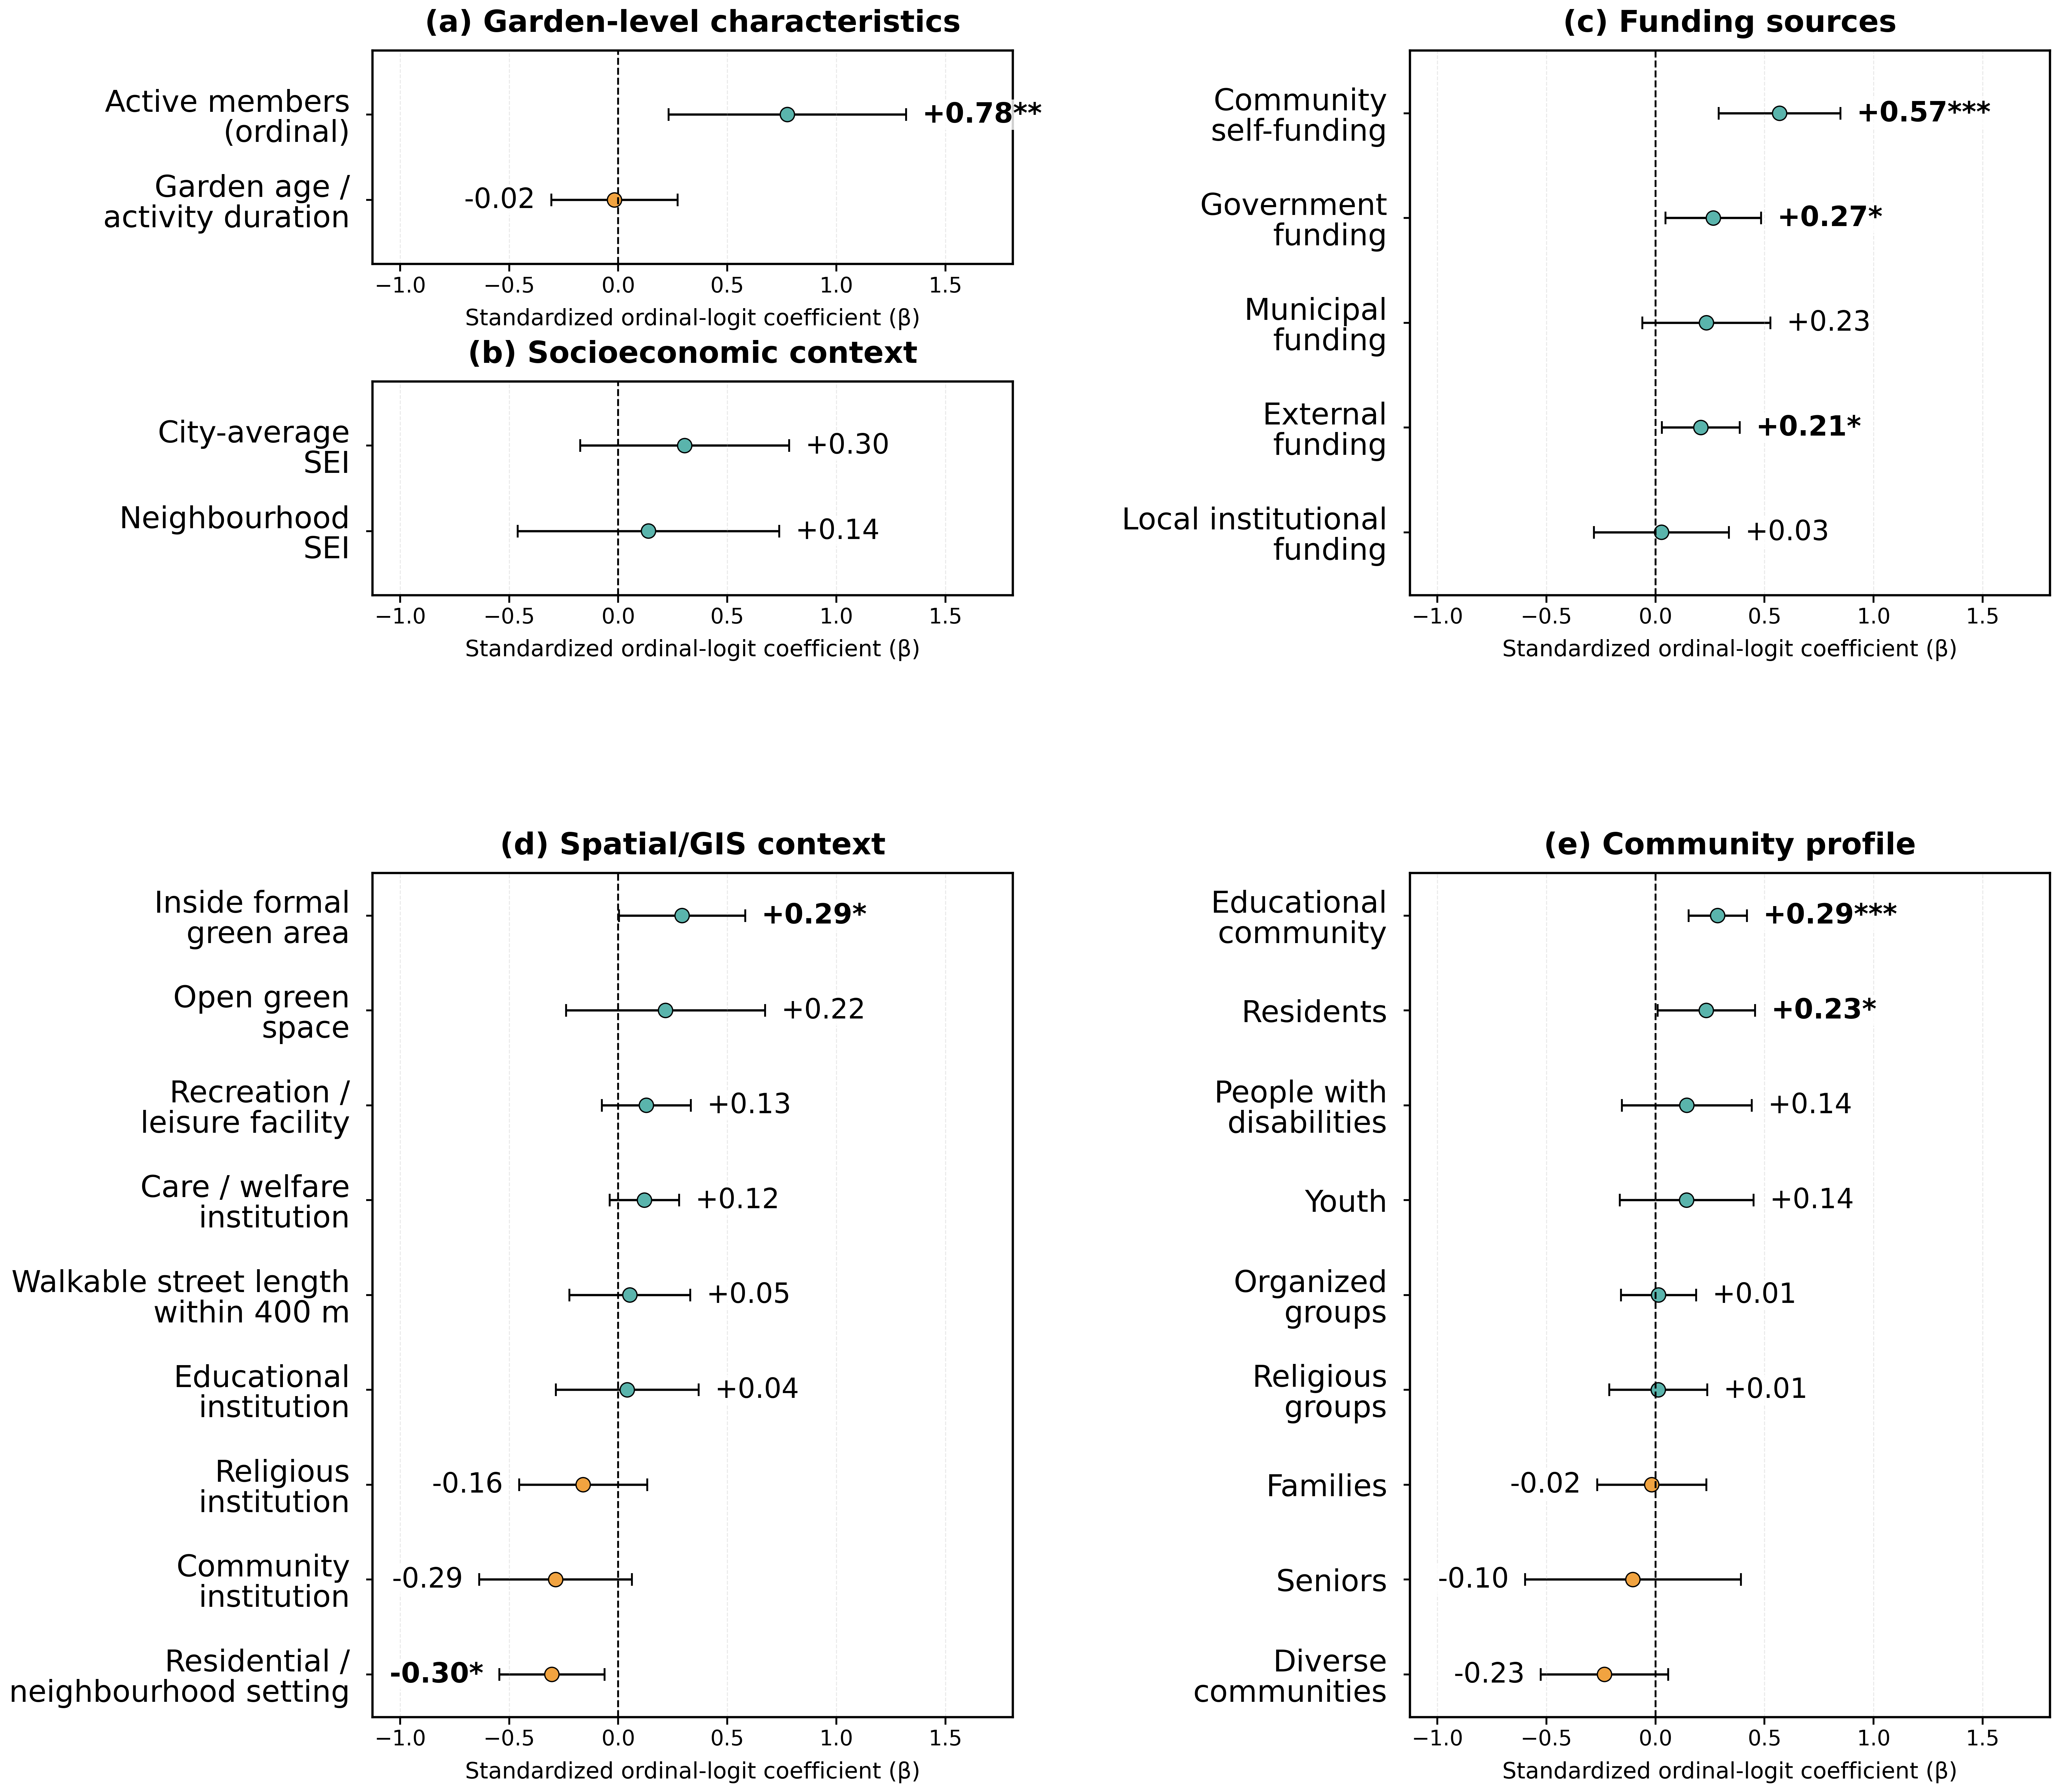

In [15]:
# ============================================================
# 15. Main adjusted figure
# ============================================================

def plot_multivariable_custom_layout(
    results,
    filename="ordinal_multivariable_custom_layout_CLEAN.png",
):
    plot_df = results.dropna(
        subset=["coef", "lower", "upper"]
    ).copy()

    if plot_df.empty:
        raise ValueError("No valid adjusted coefficients to plot.")

    required_dimensions = set(
        ADJUSTED_PREDICTORS_BY_DIMENSION
    )
    available_dimensions = set(plot_df["dimension"])

    missing_dimensions = required_dimensions - available_dimensions
    if missing_dimensions:
        raise ValueError(
            "Adjusted figure cannot be produced because these "
            "dimension models have no coefficient results:\n"
            + "\n".join(sorted(missing_dimensions))
        )

    x_min = float(plot_df["lower"].min())
    x_max = float(plot_df["upper"].max())
    x_range = max(x_max - x_min, 0.1)
    x_pad = 0.25 * x_range
    xlim = (x_min - x_pad, x_max + x_pad)

    # Taller bottom row because Spatial/GIS and Community each
    # now contain nine prespecified predictors.
    fig = plt.figure(
        figsize=(24, 24),
        dpi=300,
    )

    title_fs = 24
    xlabel_fs = 18
    xtick_fs = 17
    ytick_fs = 24
    coef_fs = 22

    outer = GridSpec(
        2,
        2,
        figure=fig,
        width_ratios=[1, 1],
        height_ratios=[1.0, 1.55],
        wspace=0.62,
        hspace=0.40,
    )

    top_left = GridSpecFromSubplotSpec(
        2,
        1,
        subplot_spec=outer[0, 0],
        height_ratios=[1, 1],
        hspace=0.55,
    )

    axes = {
        "Garden-level characteristics": fig.add_subplot(top_left[0, 0]),
        "Socioeconomic context": fig.add_subplot(top_left[1, 0]),
        "Funding sources": fig.add_subplot(outer[0, 1]),
        "Spatial/GIS context": fig.add_subplot(outer[1, 0]),
        "Community profile": fig.add_subplot(outer[1, 1]),
    }

    panel_labels = {
        "Garden-level characteristics": "(a)",
        "Socioeconomic context": "(b)",
        "Funding sources": "(c)",
        "Spatial/GIS context": "(d)",
        "Community profile": "(e)",
    }

    label_map = {
        "Active members (ordinal)":
            "Active members\n(ordinal)",
        "Garden age / activity duration":
            "Garden age /\nactivity duration",

        "Neighbourhood SEI (1–10)":
            "Neighbourhood\nSEI",
        "City-average SEI":
            "City-average\nSEI",

        "Municipal funding":
            "Municipal\nfunding",
        "Community self-funding":
            "Community\nself-funding",
        "Government funding":
            "Government\nfunding",
        "Local institutional funding":
            "Local institutional\nfunding",
        "External funding":
            "External\nfunding",

        "Inside formal green area":
            "Inside formal\ngreen area",
        "Walkable street length within 400 m":
            "Walkable street length\nwithin 400 m",
        "Open green space":
            "Open green\nspace",
        "Community institution":
            "Community\ninstitution",
        "Educational institution":
            "Educational\ninstitution",
        "Residential / neighbourhood setting":
            "Residential /\nneighbourhood setting",
        "Care / welfare institution":
            "Care / welfare\ninstitution",
        "Religious institution":
            "Religious\ninstitution",
        "Recreation / leisure facility":
            "Recreation /\nleisure facility",

        "Educational community":
            "Educational\ncommunity",
        "Organized groups":
            "Organized\ngroups",
        "Diverse communities":
            "Diverse\ncommunities",
        "People with disabilities":
            "People with\ndisabilities",
        "Religious groups":
            "Religious\ngroups",
    }

    def draw_panel(ax, dimension):
        sub = (
            plot_df.loc[
                plot_df["dimension"] == dimension
            ]
            .sort_values("coef", ascending=True)
            .reset_index(drop=True)
        )

        y = np.arange(len(sub))

        colors = np.where(
            sub["coef"] >= 0,
            "#5ab4ac",
            "#f1a340",
        )

        xerr = np.vstack([
            sub["coef"] - sub["lower"],
            sub["upper"] - sub["coef"],
        ])

        ax.errorbar(
            sub["coef"],
            y,
            xerr=xerr,
            fmt="none",
            ecolor="black",
            elinewidth=1.8,
            capsize=5,
            capthick=1.5,
            zorder=1,
        )

        ax.scatter(
            sub["coef"],
            y,
            s=130,
            c=colors,
            edgecolor="black",
            linewidth=1.0,
            zorder=2,
        )

        offset = 0.025 * (xlim[1] - xlim[0])

        for yi, (_, row) in zip(y, sub.iterrows()):
            text = f"{row['coef']:+.2f}{row['stars']}"

            if row["coef"] >= 0:
                x_text = row["upper"] + offset
                ha = "left"
            else:
                x_text = row["lower"] - offset
                ha = "right"

            ax.text(
                x_text,
                yi,
                text,
                va="center",
                ha=ha,
                fontsize=coef_fs,
                fontweight="bold" if row["stars"] else "normal",
                bbox={
                    "facecolor": "white",
                    "edgecolor": "none",
                    "alpha": 0.82,
                    "pad": 1.4,
                },
                zorder=5,
            )

        ax.axvline(
            0,
            color="black",
            linestyle="--",
            linewidth=1.5,
        )

        ax.grid(
            axis="x",
            linestyle="--",
            linewidth=0.8,
            alpha=0.28,
        )

        display_labels = [
            label_map.get(
                str(label).strip(),
                str(label).strip(),
            )
            for label in sub["label"]
        ]

        ax.set_yticks(y)
        ax.set_yticklabels(
            display_labels,
            fontsize=ytick_fs,
            linespacing=1.05,
        )

        ax.tick_params(
            axis="y",
            labelsize=ytick_fs,
            width=1.5,
            length=5,
            pad=13,
        )
        ax.tick_params(
            axis="x",
            labelsize=xtick_fs,
            width=1.5,
            length=6,
        )

        for spine in ax.spines.values():
            spine.set_linewidth(1.8)
            spine.set_color("black")

        # Small dimensions receive additional top/bottom breathing room.
        if len(sub) <= 2:
            ax.set_ylim(-0.75, len(sub) - 1 + 0.75)
        elif len(sub) <= 5:
            ax.set_ylim(-0.60, len(sub) - 1 + 0.60)
        else:
            ax.set_ylim(-0.45, len(sub) - 1 + 0.45)

        ax.set_xlim(*xlim)

        ax.set_title(
            f"{panel_labels[dimension]} {dimension}",
            fontsize=title_fs,
            fontweight="bold",
            pad=15,
        )

        ax.set_xlabel(
            "Standardized ordinal-logit coefficient (β)",
            fontsize=xlabel_fs,
            labelpad=9,
        )

    for dimension, ax in axes.items():
        draw_panel(ax, dimension)

    fig.tight_layout(
        rect=[0.015, 0.015, 0.985, 0.985],
        pad=2.0,
        w_pad=3.0,
        h_pad=2.5,
    )

    safe_savefig(
        fig,
        OUTPUT_DIR,
        filename,
        dpi=400,
    )

    plt.show()


plot_multivariable_custom_layout(
    multivariable_results,
)


In [16]:
# ============================================================
# 16. Analysis-sample table generated from the fitted models
# ============================================================

sample_rows = [
    {
        "Analysis": "Full geocoded inventory",
        "Gardens (n)": len(df),
        "Cities (n)": df[CITY].nunique(dropna=True),
    },
    {
        "Analysis": "Annual visit category available",
        "Gardens (n)": int(df["visitors_ord"].notna().sum()),
        "Cities (n)": df.loc[
            df["visitors_ord"].notna(),
            CITY,
        ].nunique(),
    },
    {
        "Analysis": "Active membership + annual visit data",
        "Gardens (n)": int(
            df[["visitors_ord", "active_members_ord"]]
            .dropna()
            .shape[0]
        ),
        "Cities (n)": df.dropna(
            subset=["visitors_ord", "active_members_ord"]
        )[CITY].nunique(),
    },
]

for _, row in model_summary.iterrows():
    sample_rows.append({
        "Analysis": f"{row['dimension']} adjusted model",
        "Gardens (n)": row["n"],
        "Cities (n)": row["n_cities"],
    })

sample_rows.append({
    "Analysis": "Common sample for AIC/BIC comparison",
    "Gardens (n)": len(common_model_sample),
    "Cities (n)": common_model_sample[CITY].nunique(),
})

analysis_sample_table = pd.DataFrame(sample_rows)

analysis_sample_table.to_csv(
    OUTPUT_DIR / "Supplementary_regression_analysis_samples_CLEAN.csv",
    index=False,
    encoding="utf-8-sig",
)

display(analysis_sample_table)


,Analysis,Gardens (n),Cities (n)
0,Full geocoded inventory,291,16
1,Annual visit category available,214,13
2,Active membership + annual visit data,200,13
3,Garden-level characteristics adjusted model,199,13
4,Socioeconomic context adjusted model,214,13
5,Funding sources adjusted model,214,13
6,Spatial/GIS context adjusted model,214,13
7,Community profile adjusted model,214,13
8,Common sample for AIC/BIC comparison,199,13


In [17]:
# ============================================================
# 17. Optional sensitivity analysis:
# numeric representative values for annual-visit categories
# ============================================================
# This does NOT replace the ordinal models. It is an optional
# sensitivity analysis only.
#
# It uses visitors_ord directly, avoiding fragile raw-string
# mappings such as '100-500' vs '100 to 500'.
# ============================================================

def run_numeric_visit_sensitivity(
    data,
    dimensions,
    top_values=(12000, 15000, 20000, 30000),
):
    base_values = {
        0: 50,
        1: 300,
        2: 750,
        3: 3000,
        4: 7500,
    }

    rows = []

    for top_value in top_values:
        value_map = {
            **base_values,
            5: top_value,
        }

        work = data.copy()
        work["visitors_numeric"] = (
            work["visitors_ord"].map(value_map)
        )
        work["log_visitors"] = np.log1p(
            work["visitors_numeric"]
        )

        for dimension, predictors in dimensions.items():
            for predictor in predictors:

                temp = work[
                    ["log_visitors", predictor, CITY]
                ].copy()

                temp["log_visitors"] = pd.to_numeric(
                    temp["log_visitors"],
                    errors="coerce",
                )
                temp[predictor] = pd.to_numeric(
                    temp[predictor],
                    errors="coerce",
                )

                temp = temp.dropna().copy()

                if (
                    len(temp) < 30
                    or temp[CITY].nunique() < 8
                    or temp[predictor].nunique() < 2
                ):
                    continue

                temp["x_std"] = zscore(temp[predictor])
                temp["y_std"] = zscore(temp["log_visitors"])
                temp = temp.dropna(
                    subset=["x_std", "y_std"]
                ).copy()

                X = sm.add_constant(
                    temp[["x_std"]],
                    has_constant="add",
                )

                try:
                    result = sm.OLS(
                        temp["y_std"],
                        X,
                    ).fit(
                        cov_type="cluster",
                        cov_kwds={
                            "groups": temp[CITY],
                            "use_correction": True,
                        },
                        use_t=True,
                    )

                    ci = result.conf_int().loc["x_std"]

                    rows.append({
                        "above_10000_value": top_value,
                        "dimension": dimension,
                        "predictor": predictor,
                        "label": pretty_names[predictor],
                        "n": len(temp),
                        "n_cities": temp[CITY].nunique(),
                        "coef": float(result.params["x_std"]),
                        "lower": float(ci.iloc[0]),
                        "upper": float(ci.iloc[1]),
                        "p_value": float(result.pvalues["x_std"]),
                    })

                except Exception as exc:
                    rows.append({
                        "above_10000_value": top_value,
                        "dimension": dimension,
                        "predictor": predictor,
                        "label": pretty_names[predictor],
                        "n": len(temp),
                        "n_cities": temp[CITY].nunique(),
                        "coef": np.nan,
                        "lower": np.nan,
                        "upper": np.nan,
                        "p_value": np.nan,
                        "error": repr(exc),
                    })

    out = pd.DataFrame(rows)

    if not out.empty:
        out["stars"] = out["p_value"].map(p_to_stars)

    return out


sensitivity_results = run_numeric_visit_sensitivity(
    data=df,
    dimensions=PREDICTORS_BY_DIMENSION,
)

sensitivity_results.to_csv(
    OUTPUT_DIR / "numeric_visitors_sensitivity_results_CLEAN.csv",
    index=False,
    encoding="utf-8-sig",
)

print(
    "Sensitivity analysis saved to:",
    OUTPUT_DIR / "numeric_visitors_sensitivity_results_CLEAN.csv",
)
display(sensitivity_results.head(20))


Sensitivity analysis saved to: output_statistics\numeric_visitors_sensitivity_results_CLEAN.csv


,above_10000_value,dimension,predictor,label,n,n_cities,coef,lower,upper,p_value,stars
0,12000,Garden-level characteristics,active_members_ord,Active members (ordinal),200,13,0.398024,0.168308,0.627739,0.002647,**
1,12000,Garden-level characteristics,activity_duration_ord,Garden age / activity duration,213,13,0.006456,-0.144042,0.156954,0.927077,
2,12000,Socioeconomic context,socio_eco_neighb_ord,Neighbourhood SEI group (low/middle/high),214,13,0.189802,-0.097899,0.477502,0.176163,
3,12000,Socioeconomic context,garden_sei,Neighbourhood SEI (1–10),214,13,0.174377,-0.094572,0.443326,0.183161,
4,12000,Socioeconomic context,city_avg_sei,City-average SEI,214,13,0.200360,-0.014862,0.415582,0.065318,
5,12000,Socioeconomic context,sei_gap_garden_minus_city,Neighbourhood–city SEI gap,214,13,-0.028284,-0.208523,0.151954,0.738330,
6,12000,Funding sources,num_funding_categories,Number of funding sources,214,13,0.306923,0.203650,0.410196,0.000030,***
7,12000,Funding sources,funding_municipal,Municipal funding,214,13,0.097735,0.000261,0.195209,0.049480,*
8,12000,Funding sources,funding_community_self,Community self-funding,214,13,0.273179,0.115616,0.430742,0.002635,**
9,12000,Funding sources,funding_government,Government funding,214,13,0.127315,-0.051865,0.306495,0.147547,


In [18]:
# ============================================================
# 18. Output manifest and completion check
# ============================================================
# This final cell confirms that the principal manuscript outputs
# were created and displays a complete inventory of generated files.

required_output_files = [
    "predictor_specification.csv",
    "Supplementary_binary_predictor_distribution.csv",
    "ordinal_univariate_results_by_dimension_CLEAN.csv",
    "ordinal_univariate_sorted_by_effect_CLEAN.png",
    "ordinal_univariate_sorted_by_effect_CLEAN.pdf",
    "ordinal_multivariable_model_summary_by_dimension_CLEAN.csv",
    "ordinal_multivariable_coefficients_by_dimension_CLEAN.csv",
    "ordinal_multivariable_custom_layout_CLEAN.png",
    "ordinal_multivariable_custom_layout_CLEAN.pdf",
    "proportional_odds_assumption_check.csv",
    "four_level_annual_visit_sensitivity_check.csv",
    "ordinal_dimension_AIC_BIC_common_sample_CLEAN.csv",
    "Supplementary_regression_analysis_samples_CLEAN.csv",
]

missing_outputs = [
    filename
    for filename in required_output_files
    if not (OUTPUT_DIR / filename).exists()
]

if missing_outputs:
    raise FileNotFoundError(
        "The analysis finished without creating these required outputs:\n"
        + "\n".join(f" - {filename}" for filename in missing_outputs)
    )

output_manifest = pd.DataFrame(
    [
        {
            "file": path.name,
            "format": path.suffix.lower().lstrip("."),
            "size_kb": round(path.stat().st_size / 1024, 1),
        }
        for path in sorted(OUTPUT_DIR.iterdir())
        if path.is_file()
    ]
)

print(
    f"Analysis complete: {len(output_manifest)} files were created in "
    f"{OUTPUT_DIR.resolve()}"
)
display(output_manifest)


Analysis complete: 22 files were created in C:\Users\galia\Desktop\CGs Israel Code\output_statistics


,file,format,size_kb
0,four_level_annual_visit_sensitivity_check.csv,csv,3.9
1,numeric_visitors_sensitivity_results_CLEAN.csv,csv,20.2
2,ordinal_4level_sensitivity_coefficients.csv,csv,5.7
3,ordinal_4level_sensitivity_comparison.csv,csv,6.7
4,ordinal_4level_sensitivity_model_summary.csv,csv,1.2
5,ordinal_dimension_AIC_BIC_common_sample_CLEAN.csv,csv,1.4
6,ordinal_multivariable_coefficients_by_dimensio...,csv,5.7
7,ordinal_multivariable_custom_layout_CLEAN.pdf,pdf,40.8
8,ordinal_multivariable_custom_layout_CLEAN.png,png,1594.2
9,ordinal_multivariable_design_diagnostics_CLEAN...,csv,0.4
